<h1><center>Analyse de conversations patient-thérapeute sur la santé mentale</h1>

<quote><center>La santé mentale est un enjeu majeur de la santé publique. Ce projet vise, dans un pre-
mier temps, à exploiter le jeu de données pour comprendre les types de conversations et leur
structure, puis à analyser les sentiments des échanges afin de détecter les émotions et états
psychologiques des patients. Ensuite, il se concentre sur l’accès et le traitement des conversa-
tions, en résumant les échanges et en identifiant les schémas linguistiques récurrents. Enfin, il
prévoit le développement d’un système question-réponse, capable d’automatiser les interactions
et fournir des réponses.</quote>

<center><nav>
    <b>Auteur: LARROUX Logan</b><br><i>étudiant à l'université de Toulouse en licence Informatique</i><br><br>
    <a href="https://www.kaggle.com/datasets/thedevastator/nlp-mental-health-conversations">Données</a> |
    <a href="https://github.com/cypnet/Analyse-de-conversations-sur-la-sant-mentale-/tree/Logan">Github</a>
</nav>

In [1]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
data_path = '../../data/train.csv'
df = pd.read_csv(data_path)
print(f"Détails nombre de lignes/colonnes: {df.shape}")
print(f"\nDétails des colonnes: {df.columns.tolist()}")
print(f"\nAperçu des premières lignes:")
df.head()

Détails nombre de lignes/colonnes: (3512, 2)

Détails des colonnes: ['Context', 'Response']

Aperçu des premières lignes:


,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


<h3>Nettoyage des données (pré-traitement)</h3>

<h4>Cellules vides</h4> 

In [3]:
# On doit d'abord vérifier si il y a des cellules vides pour les deux colonnes
print("\nCellules vides (avant traitement): \n",df.isnull().sum())
df = df.dropna(subset=['Response', 'Context'])
print("\nCellules vides (après traitement): \n",df.isnull().sum())


Cellules vides (avant traitement): 
 Context     0
Response    4
dtype: int64

Cellules vides (après traitement): 
 Context     0
Response    0
dtype: int64


#### Doublons de cellules

In [4]:
# On vérifie ensuite si il y a des doublons de cellules
print("\nCellules dupliquées (avant traitement):",df.duplicated().sum())
df = df.drop_duplicates()
print("\nCellules dupliquées (après traitement):",df.duplicated().sum())


Cellules dupliquées (avant traitement): 760

Cellules dupliquées (après traitement): 0


In [5]:
# On vérifie que toute les cellules soient du type String et si ce n'est pas le cas (NaN) les remplacer par ''
df['Response'] = df['Response'].fillna('').astype(str)

# On regarde si les cellules Response et Context sont unique, si ce n'est pas le cas alors on supprimme les dupliquées
df = df.drop_duplicates(subset=['Response', 'Context'])

#### Garder que les mots anglais

Dans le corpus, on peut remarquer certains mots qui sont en espagnol, pour être sur de ne pas les traiter, on va les retirer en utilisant ```langdetect```

In [6]:
from langdetect import detect, LangDetectException

In [7]:
def is_english_text(text):
    """Retourne True si le texte est détecté comme anglais."""
    try:
        return detect(str(text)) == 'en'
    except LangDetectException:
        return True  # texte trop court pour détecter → on garde

# Filtrer les lignes non-anglaises
mask = df['Context'].apply(is_english_text) & df['Response'].apply(is_english_text)

print(f"Lignes totales          : {len(df)}")
print(f"Lignes anglaises        : {mask.sum()}")
print(f"Lignes filtrées (autres): {(~mask).sum()}")

df = df[mask].reset_index(drop=True)

Lignes totales          : 2748
Lignes anglaises        : 2696
Lignes filtrées (autres): 52


#### Passer tout les mots en minuscules
Transformer tout les mots en minuscules nous permettra par la suite de les traiter plus facilement et éviter des situations telle que "toto" soit différent de "Toto".

In [8]:
# compter les majuscules AVANT traitement
df['Response_upper'] = df['Response'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
df['Context_upper'] = df['Context'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

print("\nNombre de majuscules dans Response (avant):", df['Response_upper'].sum())
print("Nombre de majuscules dans Context (avant):", df['Context_upper'].sum())

# transformer le texte en minuscules
df['Response'] = df['Response'].str.lower()
df['Context'] = df['Context'].str.lower()


# compter les majuscules APRES traitement
df['Response_upper_after'] = df['Response'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
df['Context_upper_after'] = df['Context'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

print("\nNombre de majuscules dans Response (après):", df['Response_upper_after'].sum())
print("Nombre de majuscules dans Context (après):", df['Context_upper_after'].sum())


Nombre de majuscules dans Response (avant): 59767
Nombre de majuscules dans Context (avant): 20176

Nombre de majuscules dans Response (après): 0
Nombre de majuscules dans Context (après): 0


#### Suppression des espaces insécables (non-breaking space)
Un espace insécable est définit par le caractère spéciale Unicode <code>'\xa0'</code>. Celui-ci peut se retrouver dans nos données puisque le fichier csv a été récupérée depuis le web, il ne faut donc pas oublier à le retirer.

In [9]:
df['Response'] = df['Response'].str.replace(r'\s+', ' ', regex=True)
df['Context'] = df['Context'].str.replace(r'\s+', ' ', regex=True)

#### Quand est-il de la ponctuation ?
Le faire trop tôt posera problème lors de la lemmatisation que l'on fera un peu plus bas.

### Tokenisation
On va maitenant "découper" les mots de chaque cellules en <i>tokens</i>.<br>
Pour pouvoir les définir, on va utiliser la librairie <b>spaCy</b> qui est une version un peut plus moderne que nltk (The Natural Language Toolkit).

*Il faut au préalable télécharger le modèle pour pouvoir l'utiliser:</i> <code>python3 -m spacy download en_core_web_sm*</code>

In [10]:
import spacy
nlp = spacy.load("en_core_web_sm") # On charge spaCy dans python

##### Attention !
Ici on traite une grande quantité de données, tokeniser (si ça se dit...) les mots bêtements va prendre énormément de temps, puisque spacy va devoir exécuter tokenize sur chaque ligne.
On va devoir utiliser <code>nlp.pipe()</code> pour traiter les cellules en batch

In [11]:
docs_response = list(nlp.pipe(df["Response"].astype(str), batch_size=200))
docs_context = list(nlp.pipe(df["Context"].astype(str), batch_size=200))

df['Response_tokens'] = [[token.text for token in doc] for doc in docs_response]
df['Context_tokens'] = [[token.text for token in doc] for doc in docs_context]

In [12]:
# On affiche le nombre de token total
nb_tokens_response = df['Response_tokens'].apply(len).sum()
nb_tokens_context = df['Context_tokens'].apply(len).sum()
print(f"Nombre total de tokens: {nb_tokens_response + nb_tokens_context}")
print(f"\nNombre total de tokens dans Response: {nb_tokens_response}")
print(f"Nombre total de tokens dans Context: {nb_tokens_context}")

# On affiche les 5 tokens les plus fréquents dans Response et Context pour avoir un apperçu
resp_tokens = [token for tokens in df['Response_tokens'] for token in tokens]
cont_tokens = [token for tokens in df['Context_tokens'] for token in tokens]
print(f"\n5 tokens les plus fréquents dans Response: {Counter(resp_tokens).most_common(5)}")
print(f"5 tokens les plus fréquents dans Context: {Counter(cont_tokens).most_common(5)}")

Nombre total de tokens: 710183

Nombre total de tokens dans Response: 531792
Nombre total de tokens dans Context: 178391

5 tokens les plus fréquents dans Response: [('you', 21792), ('to', 19781), ('.', 19222), (',', 18403), ('the', 13053)]
5 tokens les plus fréquents dans Context: [('i', 12677), ('.', 10280), ('and', 5306), ('to', 5118), (',', 4933)]


*On remarque que la plupart des mots les plus utilisés ne sont que des mots dit "vide"...*

#### Ponctuations  
Cela nous permettra de trier les mots plus facilement plus tard.  

In [13]:
# Nombre de token "ponctuations" avant traitement
def count_ponctuation(tokens):
    return sum(1 for token in tokens if getattr(token, "is_punct", False))

nb_ponctuations_response = sum(count_ponctuation(doc) for doc in docs_response)
nb_ponctuations_context = sum(count_ponctuation(doc) for doc in docs_context)

print(f"\nNombre de tokens de ponctuation dans Response (avant traitement): {nb_ponctuations_response}")
print(f"Nombre de tokens de ponctuation dans Context (avant traitement): {nb_ponctuations_context}")

df["Response_tokens_no_punct"] = [
    [token.text for token in doc if not token.is_punct]
    for doc in docs_response
]

df["Context_tokens_no_punct"] = [
    [token.text for token in doc if not token.is_punct]
    for doc in docs_context
]

# Après suppression, avec la même logique, il ne devrait plus rester de tokens ponctuation
nb_ponctuations_response_no_punct = sum(
    count_ponctuation([token for token in doc if not token.is_punct]) for doc in docs_response
)
nb_ponctuations_context_no_punct = sum(
    count_ponctuation([token for token in doc if not token.is_punct]) for doc in docs_context
)

# Nombre de token de ponctuation après suppression
print(f"Nombre de tokens de ponctuation dans Response (après traitement): {nb_ponctuations_response_no_punct}")
print(f"Nombre de tokens de ponctuation dans Context (après traitement): {nb_ponctuations_context_no_punct}")


Nombre de tokens de ponctuation dans Response (avant traitement): 50949
Nombre de tokens de ponctuation dans Context (avant traitement): 18390
Nombre de tokens de ponctuation dans Response (après traitement): 0
Nombre de tokens de ponctuation dans Context (après traitement): 0


#### Suppression des StopWords
Des *stopwords* (ou mots vides en français) sont des mots n'ayant pas de réelle significations. Ses mots sont souvents des adverbes, des pronoms ou encore des mots de liaisons.  
*source: <a href="https://fr.wikipedia.org/wiki/Mot_vide">Wikipedia: Mot Vide</a>*

In [14]:
df["Response_tokens_no_stop"] = [
    [token.text for token in doc if not token.is_stop]
    for doc in docs_response
]

df["Context_tokens_no_stop"] = [
    [token.text for token in doc if not token.is_stop]
    for doc in docs_context
]

# On compare les résultats de tokens avec tokens_no_stop
print(f"\n5 tokens les plus fréquents dans Response (avec stopwords): {Counter(resp_tokens).most_common(5)}")
print(f"5 tokens les plus fréquents dans Response (sans stopwords): {Counter([token for tokens in df['Response_tokens_no_stop'] for token in tokens]).most_common(5)}")
print(f"\n5 tokens les plus fréquents dans Context (avec stopwords): {Counter(cont_tokens).most_common(5)}")
print(f"5 tokens les plus fréquents dans Context (sans stopwords): {Counter([token for tokens in df['Context_tokens_no_stop'] for token in tokens]).most_common(5)}")


5 tokens les plus fréquents dans Response (avec stopwords): [('you', 21792), ('to', 19781), ('.', 19222), (',', 18403), ('the', 13053)]
5 tokens les plus fréquents dans Response (sans stopwords): [('.', 19222), (',', 18403), ('"', 2780), ('feel', 2089), ('help', 1811)]

5 tokens les plus fréquents dans Context (avec stopwords): [('i', 12677), ('.', 10280), ('and', 5306), ('to', 5118), (',', 4933)]
5 tokens les plus fréquents dans Context (sans stopwords): [('.', 10280), (',', 4933), ('?', 1827), ('feel', 970), ('like', 903)]


#### Lemmatisation
Et enfin, il nous faut transformer les mots (tokens) en leurs forme de base, par exemple "running" deviendra "run", ou bien "better" deviendra "good".  
Cela permettra d'une part de diminuer drastiquement le nombre de tokens mais aussi de regrouper des mots qui sont similaires.

Tout ce qu'il y a été expliqué et traité au dessus peut se faire d'une traite dans la lemmatisation, en plus de d'autre traitements tel que:  
- Les chiffres  
- Les liens/URLs  
- Les emails  

Un traitement obligatoire quand on remarque qu'il existe ses anomalies dans les données.  

In [15]:
# renvoie oui ou non si il existe un token du type url, email, number
print(f"\nPrésence de tokens de type URL dans Response: {'Oui' if any(token.like_url for doc in docs_response for token in doc) else 'Non'}")
print(f"Présence de tokens de type URL dans Context: {'Oui' if any(token.like_url for doc in docs_context for token in doc) else 'Non'}")

print(f"\nPrésence de tokens de type Email dans Response: {'Oui' if any(token.like_email for doc in docs_response for token in doc) else 'Non'}")
print(f"Présence de tokens de type Email dans Context: {'Oui' if any(token.like_email for doc in docs_context for token in doc) else 'Non'}")

print(f"\nPrésence de tokens de type Number dans Response: {'Oui' if any(token.like_num for doc in docs_response for token in doc) else 'Non'}")
print(f"Présence de tokens de type Number dans Context: {'Oui' if any(token.like_num for doc in docs_context for token in doc) else 'Non'}")


Présence de tokens de type URL dans Response: Oui
Présence de tokens de type URL dans Context: Oui

Présence de tokens de type Email dans Response: Oui
Présence de tokens de type Email dans Context: Non

Présence de tokens de type Number dans Response: Oui
Présence de tokens de type Number dans Context: Oui


On remarque de plus que certains mots qui ne sont pas des stopwords mais qui sont beaucoup trop génériques peuvent, plus tard, fausser nos résultats. On va donc les filtrer et les retirer.

In [16]:
extra_stopwords = {
    "feel","like","want","know","time",
    "thing","good","need","year","think",
    "tell","say","come","go"
}

In [17]:
df["Response_clean"] = [
    [
        token.lemma_
        for token in doc
        if not token.is_stop        # stopwords
        and not token.is_punct      # ponctuation
        and not token.is_space      # espaces
        and not token.like_num      # chiffres
        and not token.like_url      # URLs
        and not token.like_email    # emails
        and token.is_alpha          # uniquement les tokens composés de lettres
        and token.lemma_ not in extra_stopwords

    ]
    for doc in docs_response
]

df["Context_clean"] = [
    [
        token.lemma_
        for token in doc
        if not token.is_stop        # stopwords
        and not token.is_punct      # ponctuation
        and not token.is_space      # espaces
        and not token.like_num      # chiffres
        and not token.like_url      # URLs
        and not token.like_email    # emails
        and token.is_alpha          # uniquement les tokens composés de lettres
        and token.lemma_ not in extra_stopwords
    ]
    for doc in docs_context
]

In [18]:
# On affiche maintenant le nombre de tokens après lemmatisation
nb_tokens_response_clean = df['Response_clean'].apply(len).sum()
nb_tokens_context_clean = df['Context_clean'].apply(len).sum()
print(f"Nombre total de tokens après lemmatisation: {nb_tokens_response_clean + nb_tokens_context_clean}")
print(f"\nNombre total de tokens dans Response après lemmatisation: {nb_tokens_response_clean}")
print(f"Nombre total de tokens dans Context après lemmatisation: {nb_tokens_context_clean}")

Nombre total de tokens après lemmatisation: 205114

Nombre total de tokens dans Response après lemmatisation: 161171
Nombre total de tokens dans Context après lemmatisation: 43943


In [19]:
# Apperçus du DataFrame après le traitement
df.head()

,Context,Response,Response_upper,Context_upper,Response_upper_after,Context_upper_after,Response_tokens,Context_tokens,Response_tokens_no_punct,Context_tokens_no_punct,Response_tokens_no_stop,Context_tokens_no_stop,Response_clean,Context_clean
0,i'm going through some things with my feelings...,"if everyone thinks you're worthless, then mayb...",10,10,0,0,"[if, everyone, thinks, you, 're, worthless, ,,...","[i, 'm, going, through, some, things, with, my...","[if, everyone, thinks, you, 're, worthless, th...","[i, 'm, going, through, some, things, with, my...","[thinks, worthless, ,, maybe, need, find, new,...","[going, things, feelings, ., barely, sleep, th...","[worthless, maybe, find, new, people, hang, so...","[feeling, barely, sleep, worthless, try, conte..."
1,i'm going through some things with my feelings...,"hello, and thank you for your question and see...",43,10,0,0,"[hello, ,, and, thank, you, for, your, questio...","[i, 'm, going, through, some, things, with, my...","[hello, and, thank, you, for, your, question, ...","[i, 'm, going, through, some, things, with, my...","[hello, ,, thank, question, seeking, advice, ....","[going, things, feelings, ., barely, sleep, th...","[hello, thank, question, seek, advice, feeling...","[feeling, barely, sleep, worthless, try, conte..."
2,i'm going through some things with my feelings...,first thing i'd suggest is getting the sleep y...,5,10,0,0,"[first, thing, i, 'd, suggest, is, getting, th...","[i, 'm, going, through, some, things, with, my...","[first, thing, i, 'd, suggest, is, getting, th...","[i, 'm, going, through, some, things, with, my...","[thing, suggest, getting, sleep, need, impact,...","[going, things, feelings, ., barely, sleep, th...","[suggest, get, sleep, impact, look, find, life...","[feeling, barely, sleep, worthless, try, conte..."
3,i'm going through some things with my feelings...,therapy is essential for those that are feelin...,14,10,0,0,"[therapy, is, essential, for, those, that, are...","[i, 'm, going, through, some, things, with, my...","[therapy, is, essential, for, those, that, are...","[i, 'm, going, through, some, things, with, my...","[therapy, essential, feeling, depressed, worth...","[going, things, feelings, ., barely, sleep, th...","[therapy, essential, depressed, worthless, wor...","[feeling, barely, sleep, worthless, try, conte..."
4,i'm going through some things with my feelings...,i first want to let you know that you are not ...,3,10,0,0,"[i, first, want, to, let, you, know, that, you...","[i, 'm, going, through, some, things, with, my...","[i, first, want, to, let, you, know, that, you...","[i, 'm, going, through, some, things, with, my...","[want, let, know, feelings, help, ., change, f...","[going, things, feelings, ., barely, sleep, th...","[let, feeling, help, change, feeling, change, ...","[feeling, barely, sleep, worthless, try, conte..."


*On précise bien entendu que toute les étapes peuvent se résumer dans la lemmatisation, le but ici est de détailler toutes les étapes de traitement.*

### Analyse Statistique

#### Nombre de patients uniques

Il n'y a pas vraiment de façon directe (ou du moins assez fiable) pour définir un patient d'un autre sans un identifiant, la seul façon ici serait de définir une cellule pour un patient et une cellule pour un thérapeute (**sans compter les doublons**).  
Une des suppositions que l'on peut faire serait que chaque cellules patients dupliquée serait un unique patient, celui-ci évoquant la même discussion avec différents thérapeutes.  
Cette solution peut fonctionner est très approximative, surtout pour les thérapeutes.  

In [20]:
# On compte le nombre de patients uniques dans Context
unique_patients = df['Context'].nunique()
# on compte le nombre de patients uniques dans Context_clean (en convertissant les listes en tuples pour le calcul)
unique_patients_clean = df['Context_clean'].apply(tuple).nunique()
print(f"\nNombre de patients uniques: {unique_patients}")
print(f"Nombre de patients uniques après nettoyage: {unique_patients_clean}")


Nombre de patients uniques: 821
Nombre de patients uniques après nettoyage: 820


#### Nombre de thérapeutes uniques

In [21]:
# On compte le nombre de thérapeutes uniques
unique_therapeutes = df['Response'].nunique()
# On compte le nombre de patients dans Response_clean (en convertissant les listes en tuples pour le calcul)
unique_therapeutes_clean = df['Response_clean'].apply(tuple).nunique()
print(f"Nombre de thérapeutes uniques: {unique_therapeutes}")
print(f"Nombre de thérapeutes uniques après nettoyage: {unique_therapeutes_clean}")

Nombre de thérapeutes uniques: 2406
Nombre de thérapeutes uniques après nettoyage: 1988


#### Distribution des conversations par thérapeute
On cherche ici combien de conversations peut avoir un thérapeute avec un ou plusieurs patients. Or le problème ici est que, comme au dessus, on a pas d'ID pour les thérapeutes ni pour les patients, donc aucuns moyens de déterminer le nombre de conversations par thérapeutes.  

#### Nombre d'échanges moyen par conversation
Ici, on cherche à voir le nombre de mots moyens par patients/thérapeutes.

In [22]:
# Nombre de mots moyens par patients
mean_context_w_stopwords = df['Context'].apply(len).mean()
mean_context_wo_stopwords = df['Context_tokens_no_stop'].apply(len).mean()
mean_context_w_lemmas = df['Context_clean'].apply(len).mean()
print(f"Nombre de mots moyens par patients (avec stopwords): {mean_context_w_stopwords:.2f}")
print(f"Nombre de mots moyens par patients (sans stopwords): {mean_context_wo_stopwords:.2f}")
print(f"Nombre de mots moyens par patients (avec lemmatisation): {mean_context_w_lemmas:.2f}")

print("") # <br>

# Nombre de mots moyens par thérapeutes
mean_response_w_stopwords = df['Response'].apply(len).mean()
mean_response_wo_stopwords = df['Response_tokens_no_stop'].apply(len).mean()
mean_response_w_lemmas = df['Response_clean'].apply(len).mean()
print(f"Nombre de mots moyens par thérapeutes (avec stopwords): {mean_response_w_stopwords:.2f}")
print(f"Nombre de mots moyens par thérapeutes (sans stopwords): {mean_response_wo_stopwords:.2f}")
print(f"Nombre de mots moyens par thérapeutes (avec lemmatisation): {mean_response_w_lemmas:.2f}")

Nombre de mots moyens par patients (avec stopwords): 290.84
Nombre de mots moyens par patients (sans stopwords): 26.56
Nombre de mots moyens par patients (avec lemmatisation): 16.30

Nombre de mots moyens par thérapeutes (avec stopwords): 1011.84
Nombre de mots moyens par thérapeutes (sans stopwords): 88.07
Nombre de mots moyens par thérapeutes (avec lemmatisation): 59.78


On regarde **qui parle le plus entre les thérapeutes et les patients** et **le ratio**

In [23]:
# Avec stopwords
if mean_response_wo_stopwords > mean_context_wo_stopwords: 
    print("\nEn moyenne, les thérapeutes utilisent plus de mots que les patients (avec stopwords).")
    print(f"Les thérapeutes utilisent {(mean_context_w_stopwords / mean_response_w_stopwords)*100:.2f}% plus de mots que les patients (avec stopwords).")
else:
    print("\nEn moyenne, les patients utilisent plus de mots que les thérapeutes (avec stopwords).")
    print(f"Les patients utilisent {mean_context_w_stopwords / mean_response_w_stopwords*100:.2f}% plus de mots que les thérapeutes (avec stopwords).")

# Avec lemmatisation
if mean_response_w_lemmas > mean_context_w_lemmas: 
    print("\nEn moyenne, les thérapeutes utilisent plus de mots que les patients (avec lemmatisation).")
    print(f"Les thérapeutes utilisent {(mean_context_w_lemmas / mean_response_w_lemmas)*100:.2f}% plus de mots que les patients (avec lemmatisation).")
else:
    print("\nEn moyenne, les patients utilisent plus de mots que les thérapeutes (avec lemmatisation).")
    print(f"Les patients utilisent {mean_context_w_lemmas / mean_response_w_lemmas*100:.2f}% plus de mots que les thérapeutes (avec lemmatisation).")


En moyenne, les thérapeutes utilisent plus de mots que les patients (avec stopwords).
Les thérapeutes utilisent 28.74% plus de mots que les patients (avec stopwords).

En moyenne, les thérapeutes utilisent plus de mots que les patients (avec lemmatisation).
Les thérapeutes utilisent 27.26% plus de mots que les patients (avec lemmatisation).


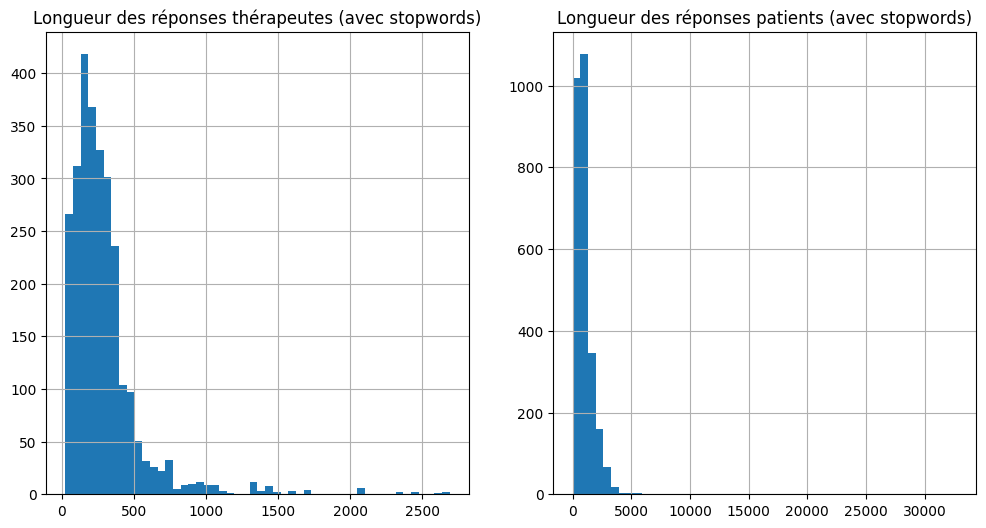

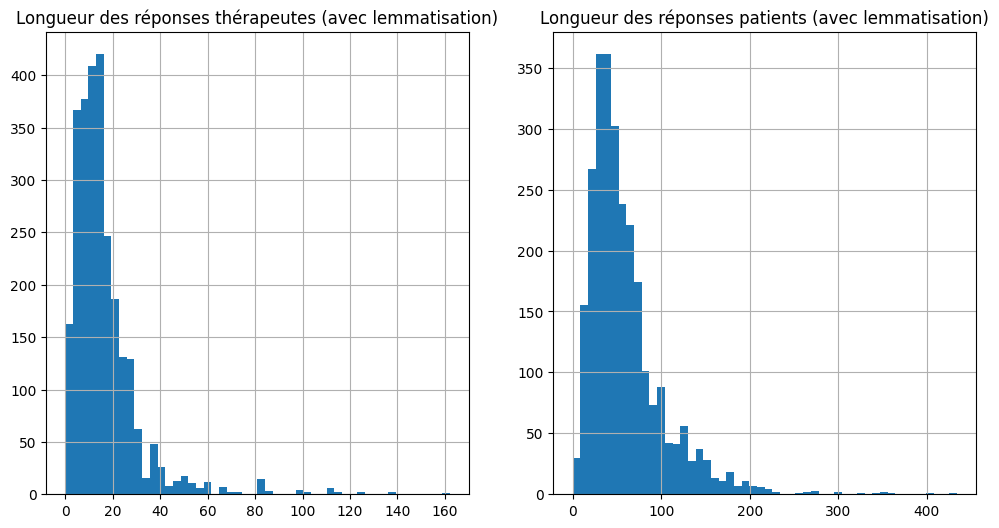

In [24]:
# Affichage de l'histogramme AVEC stopwords
plt.figure(figsize=(12, 6))

plt.subplot(121)
df['Context'].apply(len).hist(bins=50)
plt.title("Longueur des réponses thérapeutes (avec stopwords)")
plt.subplot(122)
df['Response'].apply(len).hist(bins=50)
plt.title("Longueur des réponses patients (avec stopwords)")
plt.show()

# Affichage de l'histogramme AVEC lemmatisation
plt.figure(figsize=(12, 6))
plt.subplot(121)
df['Context_clean'].apply(len).hist(bins=50)
plt.title("Longueur des réponses thérapeutes (avec lemmatisation)")
plt.subplot(122)
df['Response_clean'].apply(len).hist(bins=50)
plt.title("Longueur des réponses patients (avec lemmatisation)")
plt.show()

#### Mots les plus utilisés

In [25]:
# Liste des tokens de contexte_clean (patients)
context_tokens = [token for tokens in df['Context_clean'] for token in tokens if len(token) > 1]
# Liste des tokens de response_clean (thérapeutes)
response_tokens = [token for tokens in df['Response_clean'] for token in tokens if len(token) > 1]

# On créer un graphique avec la liste de tout les mots et leurs nombre d'apparition sur tout le corpus
all_tokens = context_tokens + response_tokens

# Nettoyage des tokens courts (contractions résiduelles comme "m" / "s" après suppression de ponctuation)
all_tokens = [token for token in all_tokens if len(token) > 1]

# Re-compter les tokens
all_token_counts = Counter(all_tokens)

# Top 3 mots les plus fréquents (mis en évidence en rouge)
top3_context = Counter(context_tokens).most_common(3)
top3_response = Counter(response_tokens).most_common(3)
top3 = Counter(context_tokens + response_tokens).most_common(3)

top3_context_tokens = [token for token, _ in top3_context]
top3_response_tokens = [token for token, _ in top3_response]

top3_tokens = [token for token, _ in top3]

# Préparer les données pour affichage (top 30 pour lisibilité)
top_n = 30
most_common_context = Counter(context_tokens).most_common(top_n)
most_common_response = Counter(response_tokens).most_common(top_n)
most_common = all_token_counts.most_common(top_n)

top_words_context = [token for token, _ in most_common_context]
top_counts_context = [count for _, count in most_common_context]

top_words_response = [token for token, _ in most_common_response]
top_counts_response = [count for _, count in most_common_response]

top_words = [token for token, _ in most_common]
top_counts = [count for _, count in most_common]

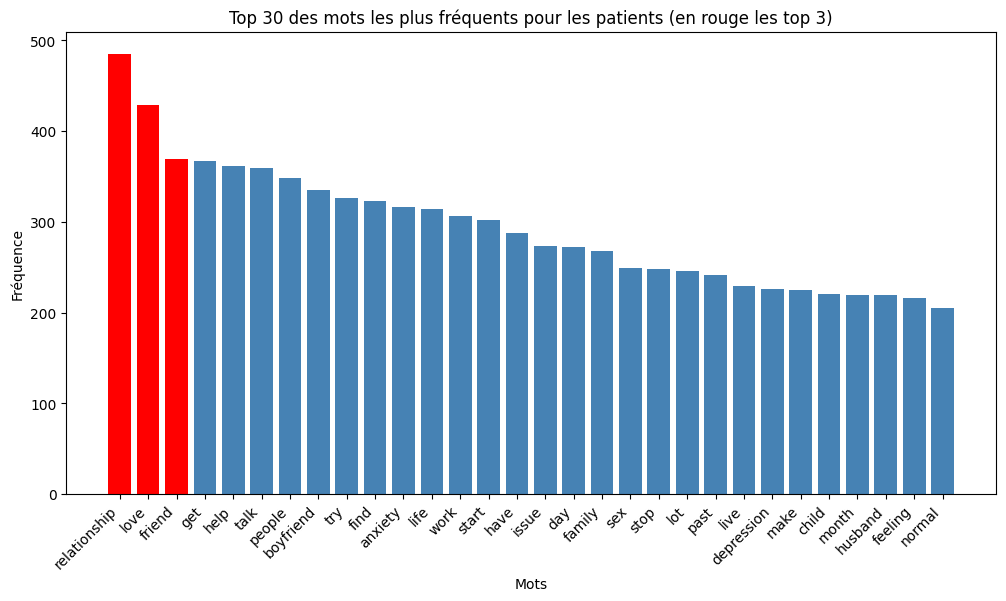

In [26]:
plt.figure(figsize=(12, 6))
bars = plt.bar(top_words_context, top_counts_context, color=['red' if token in top3_context_tokens else 'steelblue' for token in top_words_context])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 des mots les plus fréquents pour les patients (en rouge les top 3)')
plt.show()

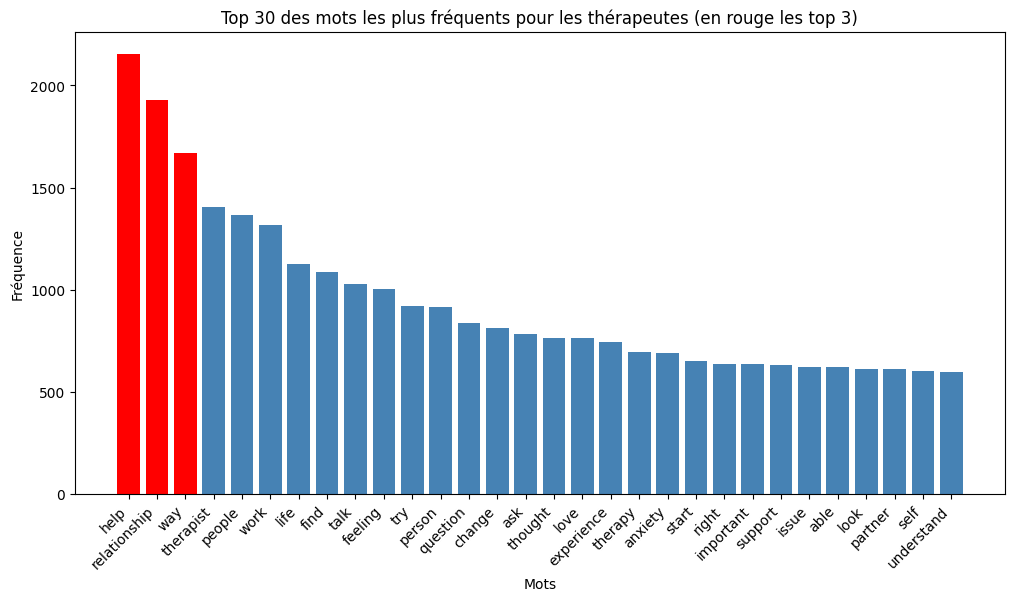

In [27]:
plt.figure(figsize=(12, 6))
bars = plt.bar(top_words_response, top_counts_response, color=['red' if token in top3_response_tokens else 'steelblue' for token in top_words_response])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 des mots les plus fréquents pour les thérapeutes (en rouge les top 3)')
plt.show()

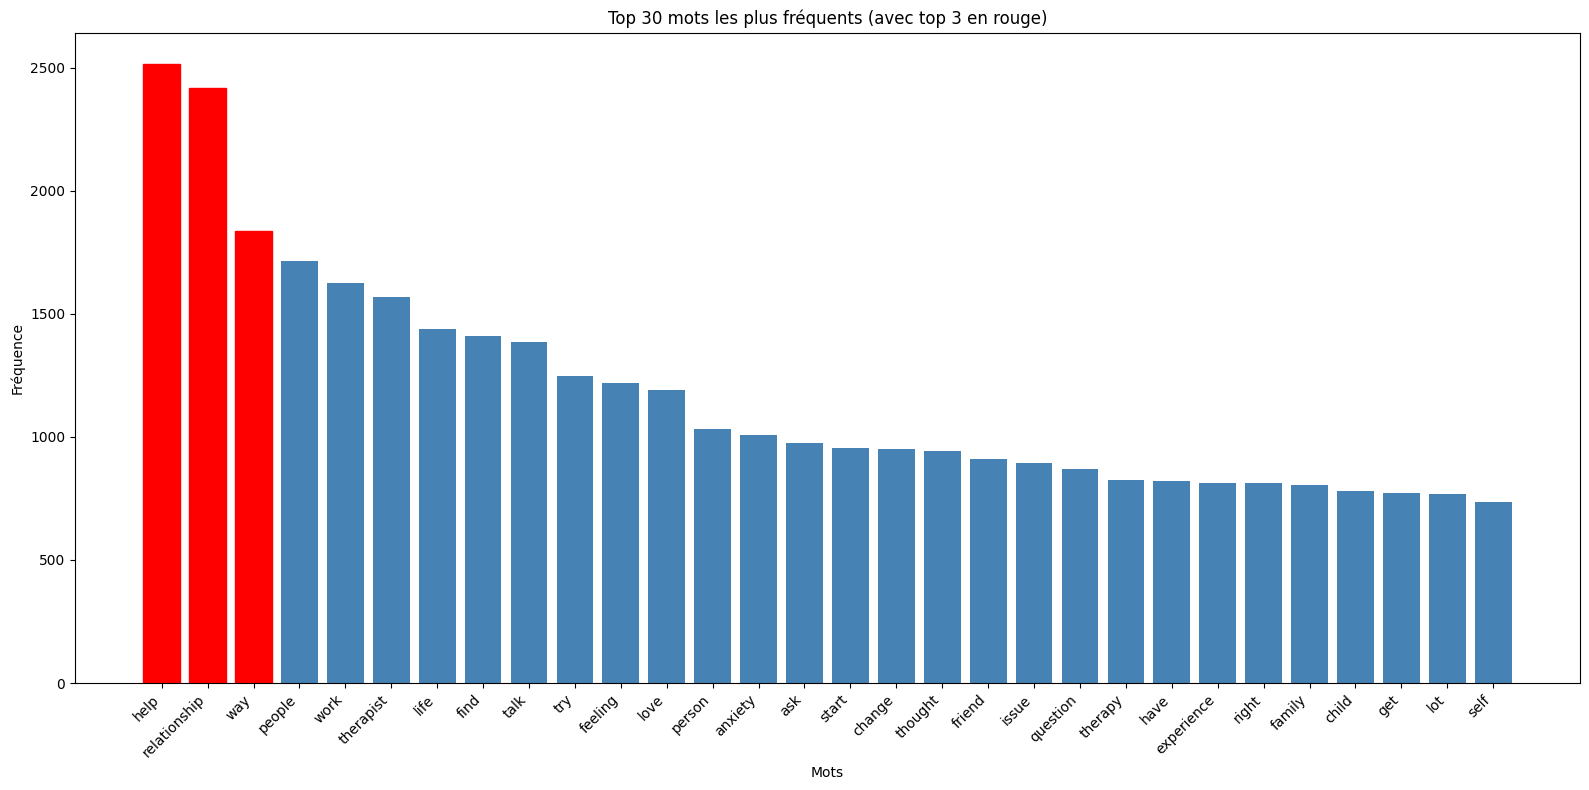

Top 3 mots les plus fréquents pour les patients:
- relationship: 485 fois
- love: 429 fois
- friend: 369 fois

Top 3 mots les plus fréquents pour les thérapeutes:
- help: 2154 fois
- relationship: 1931 fois
- way: 1670 fois

Trois mots les plus utilisés:
- help: 2516 fois
- relationship: 2416 fois
- way: 1838 fois


In [28]:
plt.figure(figsize=(16, 8))
bars = plt.bar(top_words, top_counts, color=['red' if w in top3_tokens else 'steelblue' for w in top_words])

for i, (word, count) in enumerate(most_common):
    if word in top3_tokens:
        bars[i].set_color('red')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 mots les plus fréquents (avec top 3 en rouge)')
plt.tight_layout()
plt.show()

# Afficher les 3 mots les plus utilisés
print(f"Top 3 mots les plus fréquents pour les patients:")
for token, freq in top3_context:
    print(f'- {token}: {freq} fois')

print(f"\nTop 3 mots les plus fréquents pour les thérapeutes:")
for token, freq in top3_response:
    print(f'- {token}: {freq} fois')

print('\nTrois mots les plus utilisés:')
for token, freq in top3:
    print(f'- {token}: {freq} fois')

Si on auraient pas retiré *feel* des mots à analyser, on aurait remarqué ici que *feel* et *feeling* sont deux termes distincts, alors qu'après la lemmatisation ils auraient dû se fusionner en un seul terme *feel*. Cela viens du fait que spaCy lemmatise différemment selon le **contexte grammatical** du mot.  
Quand feeling est utilisé comme nom (*"a feeling of anxiety"*), spaCy le garde tel quel au lieu de le ramener à *feel*.  
Ensuite, *like* est un mot très ambigu en anglais. Il peut être une préposition/conjonction (*"I feel like"*), auquel cas c'est quasiment un mot vide, doù sa supression.

#### Corrélation entre patient et thérapeute
La corrélation mesure, dans notre cas, le lien qu'il peut y avoir entre la longueur des phrases du patient et du thérapeute. Voir si quand le patient parle beaucoup le thérapeute aussi ou l'inverse.  
La valeur peut aller de -1 à 1, plus la valeur se rapproche de 1, plus le lien est réel.  
Dans notre cas, si la valeur se répproche de 1, cela signifie que plus le patient parle longtemps, plus le thérapeute repond longtemps. Inversement si la valeur se rapproche de -1, plus le patient parle, moins le thérapeute reponds longtemps.

In [29]:
df['context_len'] = df['Context_clean'].apply(len)
df['response_len'] = df['Response_clean'].apply(len)
print(df[['context_len', 'response_len']].corr())

              context_len  response_len
context_len      1.000000      0.062855
response_len     0.062855      1.000000


<p>On se retrouve donc avec une <b>corrélation proche de 0</b> (~0.05).<br>
Si on voulais traduire les résultats, cela signifie qu'un patient peut très bien parler longtemps, le thérapeute lui pourra répondre de façon courte.<br>
Les réponses des thérapeutes semblent donc relativement indépendantes, cela peut s'expliquer par l'utilisation de réponses standardisées ou des réponses très "robotiques".</p>

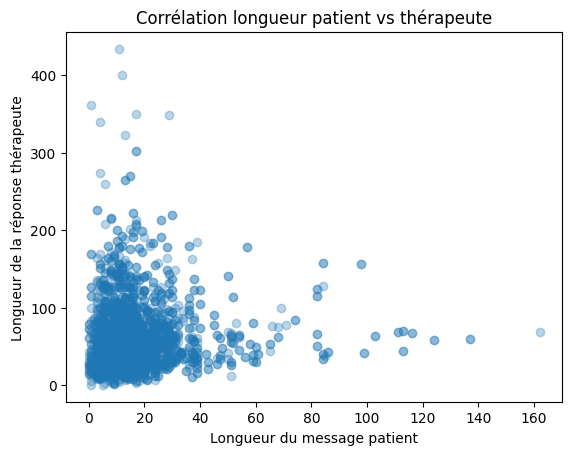

In [30]:
# Visualisation de la corrélation entre la longueur des messages patients et thérapeutes
plt.scatter(df["context_len"], df["response_len"], alpha=0.3)
plt.xlabel("Longueur du message patient")
plt.ylabel("Longueur de la réponse thérapeute")
plt.title("Corrélation longueur patient vs thérapeute")
plt.show()

### Hapax legomena
*"Un hapax ou apax est un mot qui n'a qu'une seule occurence dans un corpus donnée."*  
*source: <a href="https://fr.wikipedia.org/wiki/Hapax"> Hapax </a>*

In [31]:
# On va faire un graphe des mots les moins fréquents pour les patients et les thérapeutes
# least_common n'existe pas dans Counter, on doit utiliser most_common avec l'indexe dans les négatifs pour commencer depuis la fin

# Bottom 3 mots les plus fréquents (mis en évidence en rouge)
bottom3_context = Counter(context_tokens).most_common()[-3:]
bottom3_response = Counter(response_tokens).most_common()[-3:]

bottom3_context_tokens = [token for token, _ in bottom3_context]
bottom3_response_tokens = [token for token, _ in bottom3_response]

bottom3 = bottom3_context + bottom3_response
bottom3_tokens = [token for token, _ in bottom3]

# Préparer les données pour affichage (bottom 30 pour lisibilité)
bottom_n = 30
least_common_context = Counter(context_tokens).most_common()[-bottom_n:]
least_common_response = Counter(response_tokens).most_common()[-bottom_n:]
least_common = Counter(all_token_counts).most_common()[-bottom_n:]

bottom_words_context = [token for token, _ in least_common_context]
bottom_counts_context = [count for _, count in least_common_context]

bottom_words_response = [token for token, _ in least_common_response]
bottom_counts_response = [count for _, count in least_common_response]

bottom_words = [token for token, _ in least_common]
bottom_counts = [count for _, count in least_common]

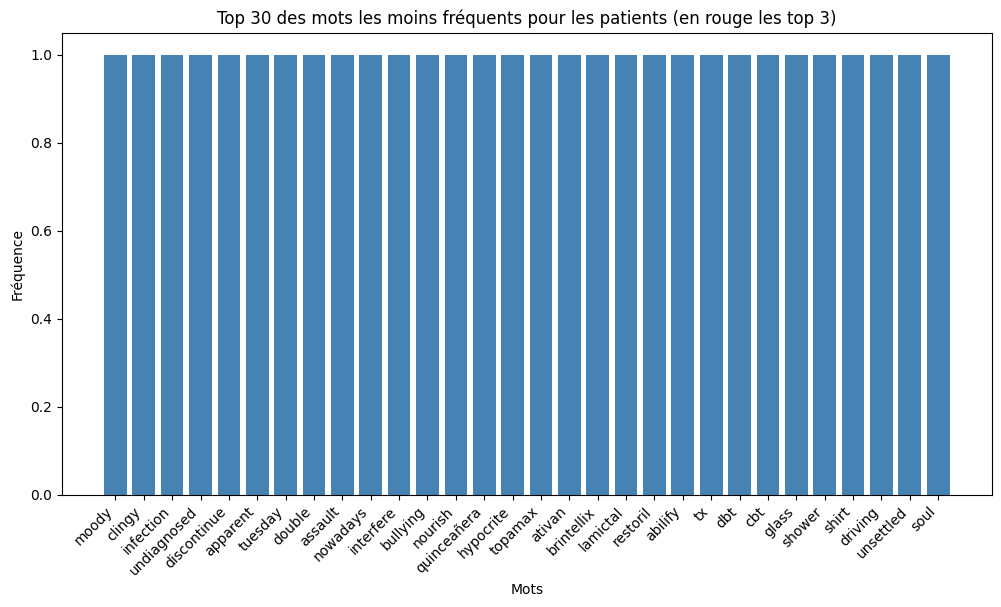

In [32]:
plt.figure(figsize=(12, 6))
bars = plt.bar(bottom_words_context, bottom_counts_context, color=['red' if token in top3_context_tokens else 'steelblue' for token in bottom_words_context])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 des mots les moins fréquents pour les patients (en rouge les top 3)')
plt.show()

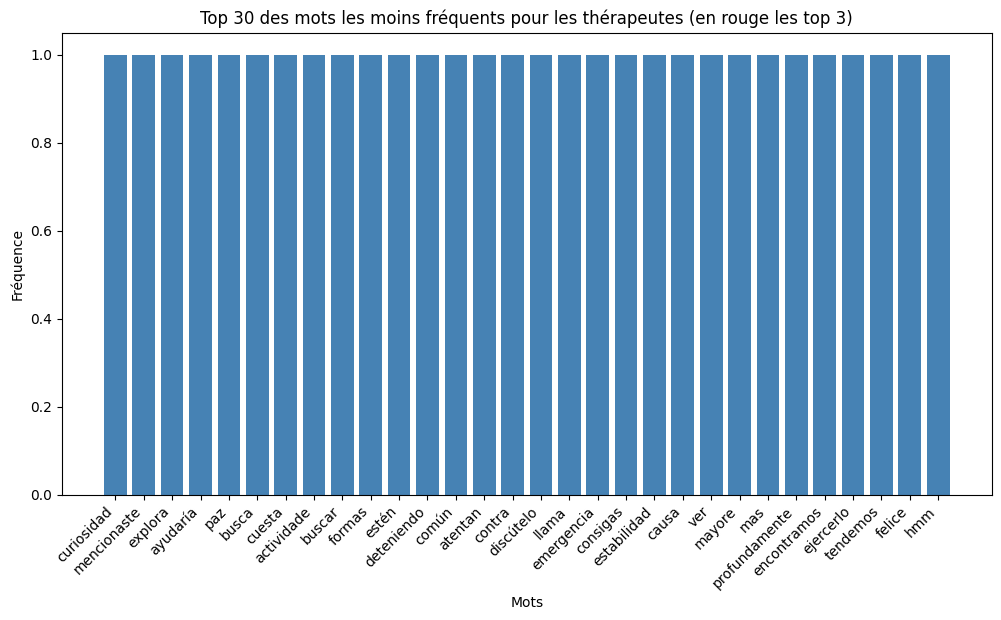

In [33]:
plt.figure(figsize=(12, 6))
bars = plt.bar(bottom_words_response, bottom_counts_response, color=['red' if token in top3_response_tokens else 'steelblue' for token in bottom_words_response])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 des mots les moins fréquents pour les thérapeutes (en rouge les top 3)')
plt.show()

On remarque que la plupart des mots sont en fait du charabia...

## Résumé des résultats obtenues

In [34]:
# Nombre de patients/thérapeutes
print(f"Nombre de patients: {unique_patients}")
print(f"Nombre de thérapeutes: {unique_therapeutes}")

# Nombre de mots moyens par patients/thérapeutes
print("\nNombre de mots moyen conversé par patients:")
print(f"Sans lemmatisation: {mean_context_w_stopwords:.2f}")
print(f"Avec lemmatisation: {mean_context_w_lemmas}")

print("\nNombre de mots moyen conversé par thérapeutes:")
print(f"Sans lemmatisation: {mean_response_w_stopwords:.2f}")
print(f"Avec lemmatisation: {mean_response_w_lemmas:.2f}")

# Les mots les plus utilisés par les patients/thérapeutes/deux
print(f"\nTop 3 mots les plus fréquents pour les patients:")
for token, freq in top3_context:
    print(f'- {token}: {freq} fois')

print(f"\nTop 3 mots les plus fréquents pour les thérapeutes:")
for token, freq in top3_response:
    print(f'- {token}: {freq} fois')

print('\nTrois mots les plus utilisés:')
for token, freq in top3:
    print(f'- {token}: {freq} fois')

# Les mots les moins utilisés par les patients/thérapeutes/deux
print(f"\nTop 3 mots les moins fréquents pour les patients:")
for token, freq in bottom3_context:
    print(f'- {token}: {freq} fois')

print(f"\nTop 3 mots les moins fréquents pour les thérapeutes:")
for token, freq in bottom3_response:
    print(f'- {token}: {freq} fois')

Nombre de patients: 821
Nombre de thérapeutes: 2406

Nombre de mots moyen conversé par patients:
Sans lemmatisation: 290.84
Avec lemmatisation: 16.29933234421365

Nombre de mots moyen conversé par thérapeutes:
Sans lemmatisation: 1011.84
Avec lemmatisation: 59.78

Top 3 mots les plus fréquents pour les patients:
- relationship: 485 fois
- love: 429 fois
- friend: 369 fois

Top 3 mots les plus fréquents pour les thérapeutes:
- help: 2154 fois
- relationship: 1931 fois
- way: 1670 fois

Trois mots les plus utilisés:
- help: 2516 fois
- relationship: 2416 fois
- way: 1838 fois

Top 3 mots les moins fréquents pour les patients:
- driving: 1 fois
- unsettled: 1 fois
- soul: 1 fois

Top 3 mots les moins fréquents pour les thérapeutes:
- tendemos: 1 fois
- felice: 1 fois
- hmm: 1 fois


## Analyse Lexicale

Maintenant que nous avons trié, traité et extrait toute les informations, il nous faut générer un **dictionnaire lexicale n-gram**.
Un n-gram est une séquence de $n$ mots consécutifs dans un texte, c'est une façon de capturer non seulement les mots isolés, mais aussi les **associations de mots fréquentes**.  
Par exemple:
- 1-gram (unigram): chaque mot est **isolé** -> ["anxiété", "sommeil" ,"stress"]
- 2-gram (bigram): les mots sont traité en **paires** -> ["anxiété sévère", "manque sommeil", "beaucoup stress"]
- 3-gram (trigram): en **triplet** -> ["Je me sens", "j'ai du mal", "depuis longtemps je"]
- ainsi de suite...

Dans notre travail, on va vouloir repérer des **formulations récurrentes** qui ont du sens:

| Type            | Exemple trouvé               | Conclusion                  |
|-                |-                             |-                            |
| Unigram         | "Anxiété" (freq: 342)        | Thème dominant              |
| Bigram          | "pensées négatives" (freq:87)| Expressions caractéristique |
| Trigram         | "j'arrive pas à" (freq:54)   | Patterne de détresse        |   

*source: https://www.geeksforgeeks.org/nlp/n-gram-in-nlp/*

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

context_texts = df['Context_clean'].apply(lambda tokens: ' '.join(tokens))
response_texts = df['Response_clean'].apply(lambda tokens: ' '.join(tokens))

In [36]:
# On va maintenant créer une fonction qui nous donne les n-grams les plus fréquants
def get_ngram_freq(texts, ngram_range=(1, 1), top_n=20, label=""):
    """
    CountVectorizer initialise le transformeur avec les paramètres suivant:
        ngram_range -> le n-gram choisi dans la fonction
        max_features -> limite le vocabulaire aux 5000 n-grams les plus fréquents
    """
    vec = CountVectorizer(ngram_range=ngram_range, max_features=5000) 
    """
    fit_transform fait deux choses:
    fit (apprentissage): 
        analyse le texte, 
        construit un vocabulaire avec tout les n-grams uniques
        se limite à max_features n-grams les plus fréquents
    transform (transformation):
        convertit chaque texte en un vecteur numérique
        colonne de la matrice -> un n-gram
        ligne de la matrice -> ligne correspondant à un texte
        cellules -> fréquences d'apparition de n-gram dans ce texte        
    """
    X = vec.fit_transform(texts)

    freq = pd.DataFrame({
        'ngram': vec.get_feature_names_out(),
        'fréquence': X.toarray().sum(axis=0)
    }).sort_values('fréquence', ascending=False).head(top_n)

    print(f"\n Top {top_n} {label}:")
    print(freq.to_string(index=False))
    return freq

#### Résultats pour unigrams

In [37]:
uni_context  = get_ngram_freq(context_texts,  (1,1), top_n= 5, label="unigrams patients")
uni_response = get_ngram_freq(response_texts, (1,1), top_n=5, label="unigrams thérapeutes")


 Top 5 unigrams patients:
       ngram  fréquence
relationship        485
        love        429
      friend        369
         get        367
        help        362

 Top 5 unigrams thérapeutes:
       ngram  fréquence
        help       2154
relationship       1931
         way       1670
   therapist       1404
      people       1365


*On remarque que les résultats obtenus pour n = 1 sont les mêmes que ceux trouvés précédement*

#### **Mais alors comment déterminer le n des n-grams ?**
Il n'y a pas de réelles façons de déterminer un $n$, tout dépends du contexte et de son utilisation, une approche pour le choisir de façon raisonnée serait d'analyser la fréquence pour chaque $n$.  
Plus le $n$ est grand moins il y aura de groupes de mots, logique, sauf que notre but ici est d'analyser un pic drastique entre les $n$, si il est beaucoup trop grand, alors ça ne sert à rien d'aller plus loin.  
Ensuite on regarde le Hapax, qui correspond au pourcentage de n-grams qui n'apparaissent qu'une seul fois (vue et traité juste au dessus), si celui-ci excède 70/80%, une grande partie des mots sont unique et donc on ne peut rien en tirer de concluant.

In [38]:
# Fonction qui définit la fréquence moyenne pour chaque n-grams
def avg_ngram_freq(texts, max_n=5):
    results = []
    for n in range(1, max_n + 1):
        vec = CountVectorizer(ngram_range=(n, n))
        X = vec.fit_transform(texts)
        freqs = np.array(X.sum(axis=0)).flatten()
        results.append({
            'n': n,
            'nb_ngrams_uniques': len(freqs),
            'freq_moyenne': freqs.mean(),
            'pct_hapax': (freqs == 1).mean() * 100  # % de n-grams vus une seule fois
        })
    return pd.DataFrame(results)

context_texts = df['Context_clean'].apply(lambda t: ' '.join(t))
response_texts = df['Response_clean'].apply(lambda t: ' '.join(t))
context_stats= avg_ngram_freq(context_texts)
response_stats = avg_ngram_freq(response_texts)
print("Stats pour les patients: \n", context_stats)
print("\nStats pour les thérapeutes: \n", response_stats)


Stats pour les patients: 
    n  nb_ngrams_uniques  freq_moyenne  pct_hapax
0  1               2474     17.749394  14.955538
1  2              12625      3.265980  29.734653
2  3              13355      2.889180  32.399850
3  4              12641      2.844633  32.552804
4  5              11870      2.816007  32.434709

Stats pour les thérapeutes: 
    n  nb_ngrams_uniques  freq_moyenne  pct_hapax
0  1               7570     21.249009  28.256275
1  2              83959      1.883789  50.993938
2  3             108452      1.433528  59.364511
3  4             108586      1.406977  60.046415
4  5             106921      1.403747  60.068649


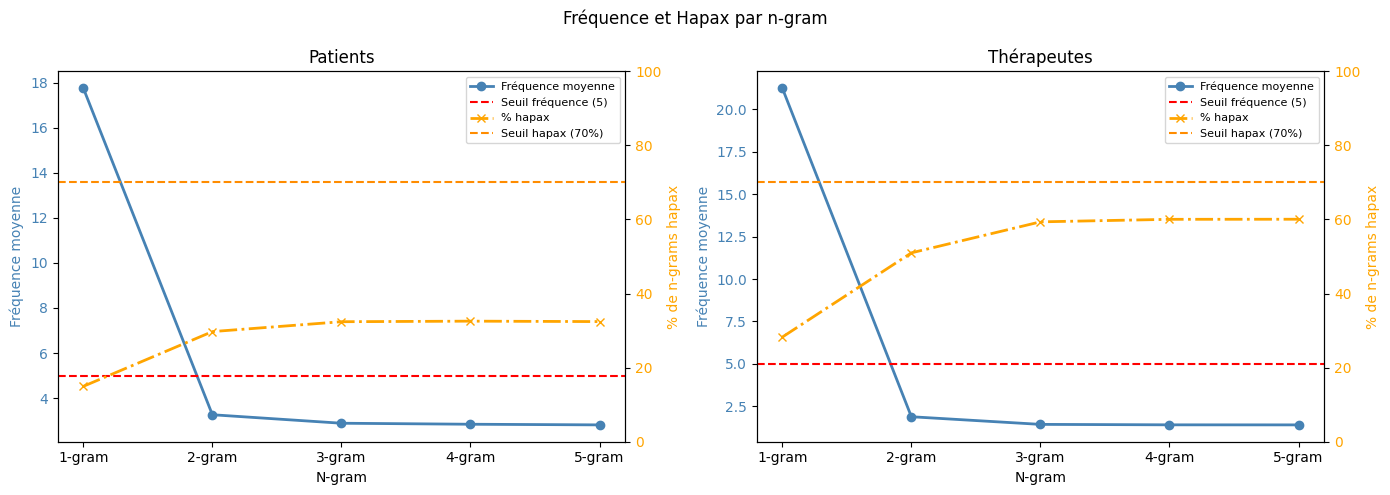

In [39]:
SEUIL_FREQ = 5
SEUIL_HAPAX = 70

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fréquence et Hapax par n-gram")

labels = [f"{n}-gram" for n in range(1, 6)]

for ax, stats, titre in zip(axes, [context_stats, response_stats], ["Patients", "Thérapeutes"]):
    ax2 = ax.twinx()  # second axe Y à droite, partage le même axe X

    # --- Axe gauche : fréquence moyenne ---
    ax.plot(labels, stats['freq_moyenne'], marker='o', color='steelblue',
            linewidth=2, label='Fréquence moyenne')
    ax.axhline(y=SEUIL_FREQ, color='red', linestyle='--', linewidth=1.5,
               label=f'Seuil fréquence ({SEUIL_FREQ})')
    ax.set_ylabel('Fréquence moyenne', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')

    # --- Axe droit : % hapax ---
    ax2.plot(labels, stats['pct_hapax'], marker='x', color='orange',
             linewidth=2, linestyle='-.', label='% hapax')
    ax2.axhline(y=SEUIL_HAPAX, color='darkorange', linestyle='--', linewidth=1.5,
                label=f'Seuil hapax ({SEUIL_HAPAX}%)')
    ax2.set_ylabel('% de n-grams hapax', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.set_ylim(0, 100)  # le % hapax va forcément de 0 à 100

    ax.set_title(titre)
    ax.set_xlabel('N-gram')

    # Légende combinée des deux axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

On remarque que à partie de $n = 1$ la fréquence a déjà drastiquement diminué, pour notre cas il est tout de même intéressant d'analyser les bigrames et trigrames, car on n'excède pas le seuil de % pour les Hapax.

<h4>Résultats pour bigrams</h4>

In [40]:
bi_context   = get_ngram_freq(context_texts,  (2,2), top_n = 5, label="bigrams patients")
bi_response  = get_ngram_freq(response_texts, (2,2), top_n = 5, label="bigrams thérapeutes")


 Top 5 bigrams patients:
         ngram  fréquence
 issue address         94
     month ago         65
   self esteem         65
  sexual abuse         56
history sexual         51

 Top 5 bigrams thérapeutes:
          ngram  fréquence
 therapist help        159
   ask question        154
  mental health        154
  family member        106
answer question        101


<h4>Résultats pour trigrams</h4>

In [41]:
tri_context  = get_ngram_freq(context_texts,  (3,3), top_n = 5, label="trigrams patients")
tri_response = get_ngram_freq(response_texts, (3,3), top_n = 5, label="trigrams thérapeutes")


 Top 5 trigrams patients:
                ngram  fréquence
 history sexual abuse         51
      low self esteem         50
session far everytime         48
   far everytime walk         48
   walk nervous shaky         48

 Top 5 trigrams thérapeutes:
                     ngram  fréquence
      hello thank question         68
mental health professional         54
          landwehr dbh lpc         51
               dbh lpc ncc         51
        robin landwehr dbh         45


<h4>Visualisation des bigrams et trigrams</h4>

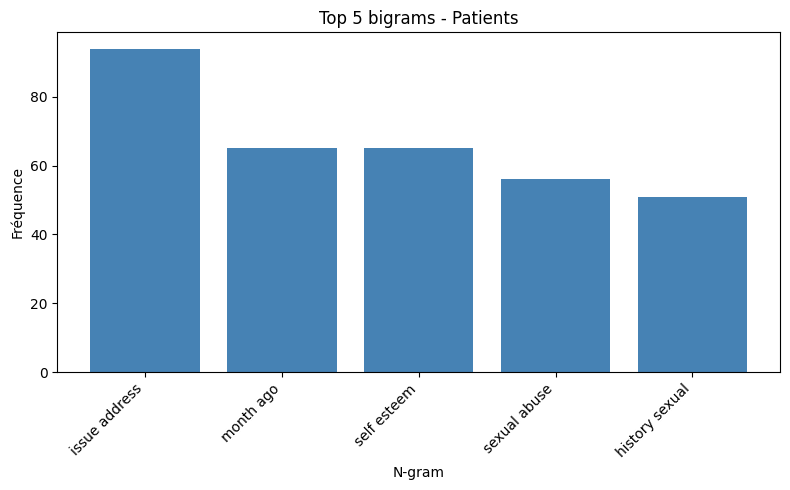

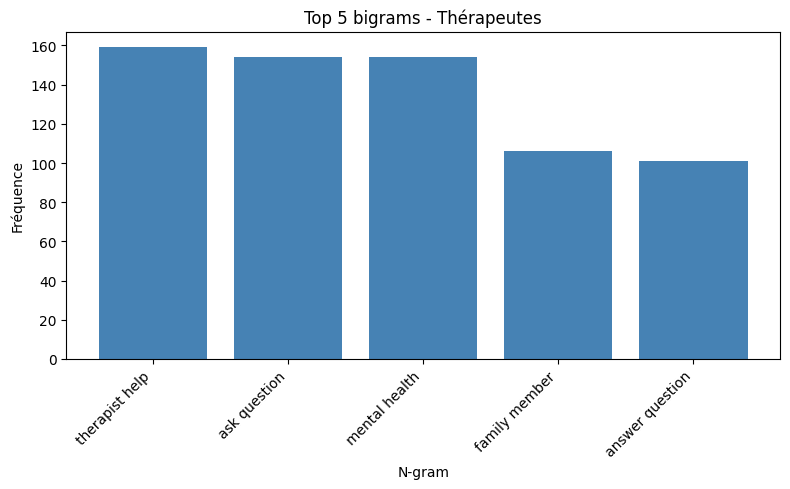

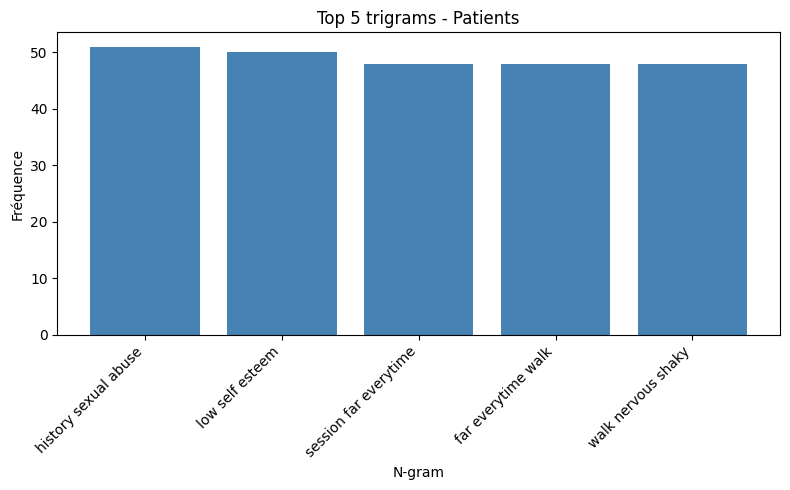

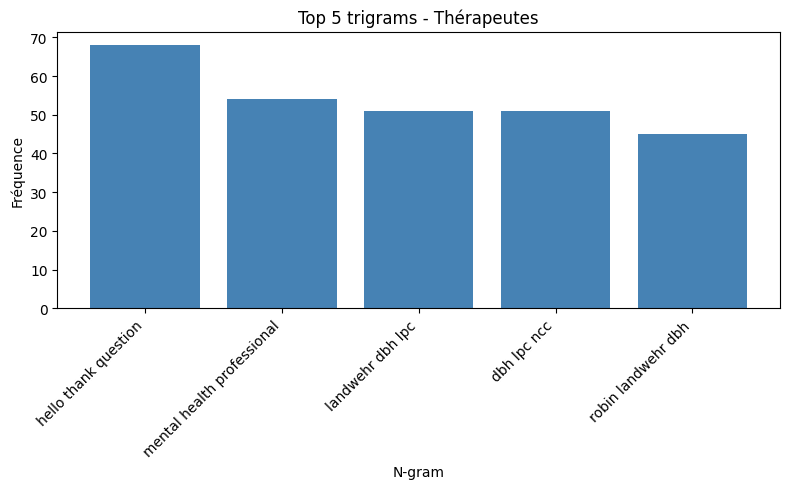

In [42]:
def plot_ngrams(freq_df, title):
    plt.figure(figsize=(8, 5))
    plt.bar(freq_df['ngram'], freq_df['fréquence'], color='steelblue')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('N-gram')
    plt.ylabel('Fréquence')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_ngrams(bi_context,  "Top 5 bigrams - Patients")
plot_ngrams(bi_response, "Top 5 bigrams - Thérapeutes")
plot_ngrams(tri_context,  "Top 5 trigrams - Patients")
plot_ngrams(tri_response, "Top 5 trigrams - Thérapeutes")

Grâce aux bigrams et trigrams, on a déjà bien plus de contexte !  
Cela nous permettra par la suite de définir des patternes et des thèmes qui nous servirons sur le **topic modeling**. 

<h2>Modélisation et extraction de sujets (Topic Modeling)</h2>

![Techniques in Embeddings in NLP](https://media.geeksforgeeks.org/wp-content/uploads/20250530170636672412/Techniques-in-Embeddings-in-NLP.webp)

<h3>Méthode 1: filtrage via un lexique métier défini manuellement</h3>

La première étape est une introduction.  
Ici, on va définir le dictionnaire à la main, avec pour chaque clée (un thème) une liste de mots qui correspondent à ce thème.

In [43]:
# Initialisation du dictionnaire de lexique
lexique = {
    "anxiété":    ["anxiety", "anxious", "worry", "nervous", "panic", "fear", "stress"],
    "dépression": ["depression", "depressed", "sad", "hopeless", "empty", "worthless"],
    "sommeil":    ["sleep", "insomnia", "nightmare", "tired", "fatigue", "wake"],
    "trauma":     ["trauma", "abuse", "ptsd", "flashback", "violent", "assault"],
    "relations":  ["relationship", "family", "friend", "lonely", "isolate", "divorce"],
}

Maintenant qu'on a définit notre dictionnaire, on va trier les mots pour les mettres dans celui-ci.

In [44]:
# Fonction qui compte le nombre d'occurrences de mots liés à chaque thème dans les réponses des patients
def count_lexique_occurrences(tokens, lexique):
    counts = {theme: 0 for theme in lexique}
    for token in tokens:
        for theme, mots in lexique.items():
            if token in mots:
                counts[theme] += 1
    return counts

In [45]:
# On l'applique sur chaque lignes de contexte_clean et response_clean
df['theme_score_context'] = df['Context_clean'].apply(lambda tokens: count_lexique_occurrences(tokens, lexique))
df['theme_score_response'] = df['Response_clean'].apply(lambda tokens: count_lexique_occurrences(tokens, lexique))

# On affiche les mots qui reviennent le plus souvent pour chaque thème
for theme, mots in lexique.items():
    context_tokens_theme = [token for tokens in df['Context_clean'] for token in tokens if token in mots]
    response_tokens_theme = [token for tokens in df['Response_clean'] for token in tokens if token in mots]
    print(f"\nThème: {theme}")
    print(f"Top 3 mots les plus fréquents pour les patients: {Counter(context_tokens_theme).most_common(3)}")
    print(f"Top 3 mots les plus fréquents pour les thérapeutes: {Counter(response_tokens_theme).most_common(3)}")



Thème: anxiété
Top 3 mots les plus fréquents pour les patients: [('anxiety', 316), ('stress', 169), ('nervous', 84)]
Top 3 mots les plus fréquents pour les thérapeutes: [('anxiety', 692), ('fear', 423), ('stress', 300)]

Thème: dépression
Top 3 mots les plus fréquents pour les patients: [('depression', 226), ('depressed', 123), ('sad', 88)]
Top 3 mots les plus fréquents pour les thérapeutes: [('depression', 396), ('sad', 120), ('depressed', 54)]

Thème: sommeil
Top 3 mots les plus fréquents pour les patients: [('sleep', 140), ('nightmare', 46), ('tired', 45)]
Top 3 mots les plus fréquents pour les thérapeutes: [('sleep', 159), ('nightmare', 55), ('wake', 27)]

Thème: trauma
Top 3 mots les plus fréquents pour les patients: [('abuse', 122), ('violent', 29), ('flashback', 16)]
Top 3 mots les plus fréquents pour les thérapeutes: [('trauma', 205), ('abuse', 188), ('ptsd', 63)]

Thème: relations
Top 3 mots les plus fréquents pour les patients: [('relationship', 485), ('friend', 369), ('fami

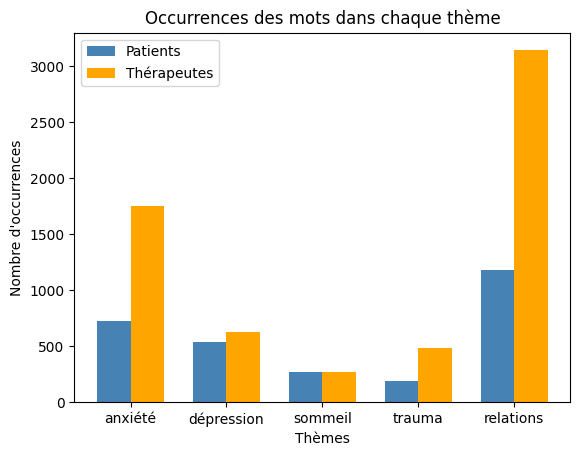

In [46]:
# On affiche en bar les scores pour patients et thérapeutes
plt.figsize=(12, 6)
themes = list(lexique.keys())
context_scores = {theme: df['theme_score_context'].apply(lambda x: x[theme]).sum() for theme in themes}
response_scores = {theme: df['theme_score_response'].apply(lambda x: x[theme]).sum() for theme in themes}
x = np.arange(len(themes))
width = 0.35
plt.bar(x - width/2, context_scores.values(), width, label='Patients', color='steelblue')
plt.bar(x + width/2, response_scores.values(), width, label='Thérapeutes', color='orange')
plt.xticks(x, themes)
plt.xlabel('Thèmes')
plt.ylabel('Nombre d\'occurrences')
plt.title('Occurrences des mots dans chaque thème')
plt.legend()
plt.show() 

On remarque depuis le graphe que les thérapeutes vont oser exprimer beaucoup plus souvent des termes liées à notre dictionnaire, en particulier les termes liés aux **relations familliale et amicale**, une conclusion qui est déjà très interessante mais **très limitée**.  
En effet, ici on utilise un dictionnaire extrèmement petit, beaucoup de mots ne sont pas traités ou sont tout simplement ignorés, par exemple *feeling* **n'appartient dans aucun thème**, ou bien un mot comme *down* pourrait être un terme lié à l'anxiété ou la dépression selon le contexte.  
Dans cette optique de vouloir aller plus loin, on va naturellement se pencher sur des méthodes qui sont bien plus aboutits et qui nous donnerons des résultats bien plus précis.

### Méthode 2: Vectorisation TF-IDF suivie d'un clustering

#### Tout d'abord, qu'est ce que le TF-IDF ?  

Viens de l'anglais *term frequency-inverse*, est une méthode de pondération utilisée en fouille de texte.  
Non seulement il calcule la "densité de mots-clés", il introduit une notion de **rareté** et de **spécificité**, cela permet d'évaluer l'importance d'un mot au sein d'un document.  

<u>Si on dépiote le terme TF-IDF:</u>
- **Term Frequency (TF)**: mesure la fréquence d'apparition d'un terme dans un document. Plus le mot est fréquent, plus le score TF est élevé.   
On le définit de façon mathématique de la sorte:  
$$
    tf_{i,j} = \frac{n_{i,j}}{\sum_k{n_{i,j}}}
$$ 
Avec:  
  - $i,j$ le nombre d'occurences du terme $i$ dans le document $j$
  - et $k$ le terme dans le document $j$

Si on devait s'arrêter là, cela signifirait que certains terme bien plus courant comme *"le"*, *"de*, ou *"et"* serait logiquement bien plus important. C'est pour cela qu'on introduit l'IDF.  

- **Inverse Document Frequency (IDF)**: Cette composante va pondérer le score en fonction de la rareté du mots dans **l'ensemble du web**. Un mot très commun aura un IDF faible et inversement pour un mot rare. On note l'équation pour l'IDF de cette façon:
$$
    idf(w) = \log({\frac{N}{df_t})}
$$
Avec:   
   - $w$ le poids des mots rares dans tout le document,  
   - $N$ le nombre total de documents  
   - et $df_t$ le nombre de documents contenant le mot $t$  

Si on combine les deux, on a alors:
$$
    w_{i,j} = tf_{i,j} \times \log(\frac{N}{df_i})
$$
*sources*:
- <a href= "https://fr.wikipedia.org/wiki/TF-IDF" > Wikipedia - TF-IDF </a>
- <a href="https://www.ledigitalpourtous.fr/2026/03/20/tf-idf-en-seo-comprendre-et-utiliser-cet-algorithme-pour-optimiser-vos-contenus/"> ledigitalpourtous - TF-IDF en SEO</a> 
- <a href="https://www.freecodecamp.org/news/how-to-process-textual-data-using-tf-idf-in-python-cd2bbc0a94a3" > freecodecomp - How to process textual data using TF-IDF in Python </a>

Dans notre cas, le traitement sera bien plus performant puisque l'on a déjà "supprimée" tout les stopwords et lemmatisé les mots. **L'IDF va mieux discriminer les termes et donc les scores seront plus significatifs**.

#### Ensuite qu'est ce que le clustering ?

Le clustering est une méthode d'analyse de données qui permet de mettre l'ordre dans un ensemble hétérogène, dans notre cas, cela consiste à regroupper des mots qui sont similaire en clusters. Prenons un exemple: les mots *"I feel sad"*, *"I am depressed"*, *"I am very happy"*, *"I feel great"* vont êtres triées dans deux cluster: un regrouppant les émotions négatives et un autre les émotions positives.

L'algorithme *K-Means* **ne comprend que des nombres**, **d'où l'importance de tranformer le texte en vecteur avec TF-IDF**.  

*On expliquera plus en détails le fonctionnement de celui-ci au moment venu (juste après TF-IDF)*

*source:*  
- <a href="https://www.spiriit.com/ressources/data-clustering-definition-methodes-usages/">Le clustering: c'est quoi exactement ?</a>

#### Préparation des textes  
Pour l'instant, on a les colonnes <code>Context_clean</code> et <code>Response_clean</code> qui contiennent la liste des tokens, sauf que TfidVectorizer attends des string, donc il faut les joindre avec <code>' '.join</code>

In [47]:
df['Context_joined'] = df['Context_clean'].apply(lambda tokens: ' '.join(tokens))
df['Response_joined'] = df['Response_clean'].apply(lambda tokens: ' '.join(tokens))
df[['Context_joined', 'Response_joined']].head()

,Context_joined,Response_joined
0,feeling barely sleep worthless try contemplate...,worthless maybe find new people hang social co...
1,feeling barely sleep worthless try contemplate...,hello thank question seek advice feeling worth...
2,feeling barely sleep worthless try contemplate...,suggest get sleep impact look find life gratef...
3,feeling barely sleep worthless try contemplate...,therapy essential depressed worthless work exp...
4,feeling barely sleep worthless try contemplate...,let feeling help change feeling change way thi...


#### Vectorisation TF-IDF

Ici on va utiliser la fonction <code>TfidfVectorizer</code>, l'avantage de cette fonction est immense, elle permet de:
- lister tout les mots uniques
- définit le score TF ($\frac{\text{fréquence des mots}}{\text{total mots}}$)
- définit un score IDF ($\log(\frac{N}{\text{docs avec mot}}$)
- définit le score final et vecteur $L2$ ($TF \times IDF + norme$)

*avec $L2$ **la mise à l'échelle des vecteurs**, cela permet que tout les vecteurs aient une longueur de 1. Ça signifie que peut importe la longueur des document, leurs scores sont comparable* 

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

# On véctorise séparément les contextes et les réponses pour pouvoir faire des analyses spécifiques à chaque type de texte
vectorizer_context = TfidfVectorizer(max_features=1000) # Max features limite le vocabulaire aux 1000 mots les plus fréquents pour éviter d'avoir une matrice trop grande
vectorizer_response = TfidfVectorizer(max_features=1000)
vectorizer_total = TfidfVectorizer(max_features=1000)

tfidf_context = vectorizer_context.fit_transform(df['Context_joined'])
tfidf_response = vectorizer_response.fit_transform(df['Response_joined'])
tfidf_total = vectorizer_total.fit_transform(df['Context_joined'] + ' ' + df['Response_joined'])

print(f"TF-IDF Context shape: {tfidf_context.shape}")
print(f"TF-IDF Response shape: {tfidf_response.shape}")
print(f"TF-IDF Total shape: {tfidf_total.shape}")


TF-IDF Context shape: (2695, 1000)
TF-IDF Response shape: (2695, 1000)
TF-IDF Total shape: (2695, 1000)


Ici, on a que la forme de la matrice avec (nombre de conversation, nombre de mots du vocabulaire).  
On va maintenant afficher les mots les plus importants pour les patients, thérapeutes et globalement.

In [50]:
# On récupère le vocabulaire (mot -> index de colonne)
feature_name_context = vectorizer_context.get_feature_names_out()
feature_name_response = vectorizer_response.get_feature_names_out()
feature_name_total = vectorizer_total.get_feature_names_out()

# On récupère le score TF-IDF moyen de chaque mot sur tout le corpus
tfidf_context_mean = np.asarray(tfidf_context.mean(axis=0)).flatten()
tfidf_response_mean = np.asarray(tfidf_response.mean(axis=0)).flatten()
tfidf_total_mean = np.asarray(tfidf_total.mean(axis=0)).flatten()

# On construit un dataframe lisible
df_scores = pd.DataFrame({
    'mot_context': feature_name_context,
    'mot_response': feature_name_response,
    'mot_total': feature_name_total,
    'tfidf_context': tfidf_context_mean,
    'tfidf_response': tfidf_response_mean,
    'tfidf_total': tfidf_total_mean
})

print("\nTop 10 mots avec leur score TF-IDF moyen pour les contextes (patients):")
print(df_scores[['mot_context', 'tfidf_context']].sort_values('tfidf_context', ascending=False).head(10))
print("\nTop 10 mots avec leur score TF-IDF moyen pour les réponses (thérapeutes):")
print(df_scores[['mot_response', 'tfidf_response']].sort_values('tfidf_response', ascending=False).head(10))
print("\nTop 10 mots avec leur score TF-IDF moyen pour le corpus total:")
print(df_scores[['mot_total', 'tfidf_total']].sort_values('tfidf_total', ascending=False).head(10))


Top 10 mots avec leur score TF-IDF moyen pour les contextes (patients):
      mot_context  tfidf_context
642        people       0.027669
714  relationship       0.026291
530          love       0.024390
424          help       0.023498
869          talk       0.021679
368        friend       0.021444
380           get       0.021438
188    counseling       0.021127
825         start       0.021081
105     boyfriend       0.019558

Top 10 mots avec leur score TF-IDF moyen pour les réponses (thérapeutes):
     mot_response  tfidf_response
747  relationship        0.045494
428          help        0.042075
911     therapist        0.035663
970           way        0.035080
651        people        0.031121
987          work        0.030369
525          life        0.028695
354          find        0.027328
897          talk        0.027172
349       feeling        0.026999

Top 10 mots avec leur score TF-IDF moyen pour le corpus total:
        mot_total  tfidf_total
736  relationship   

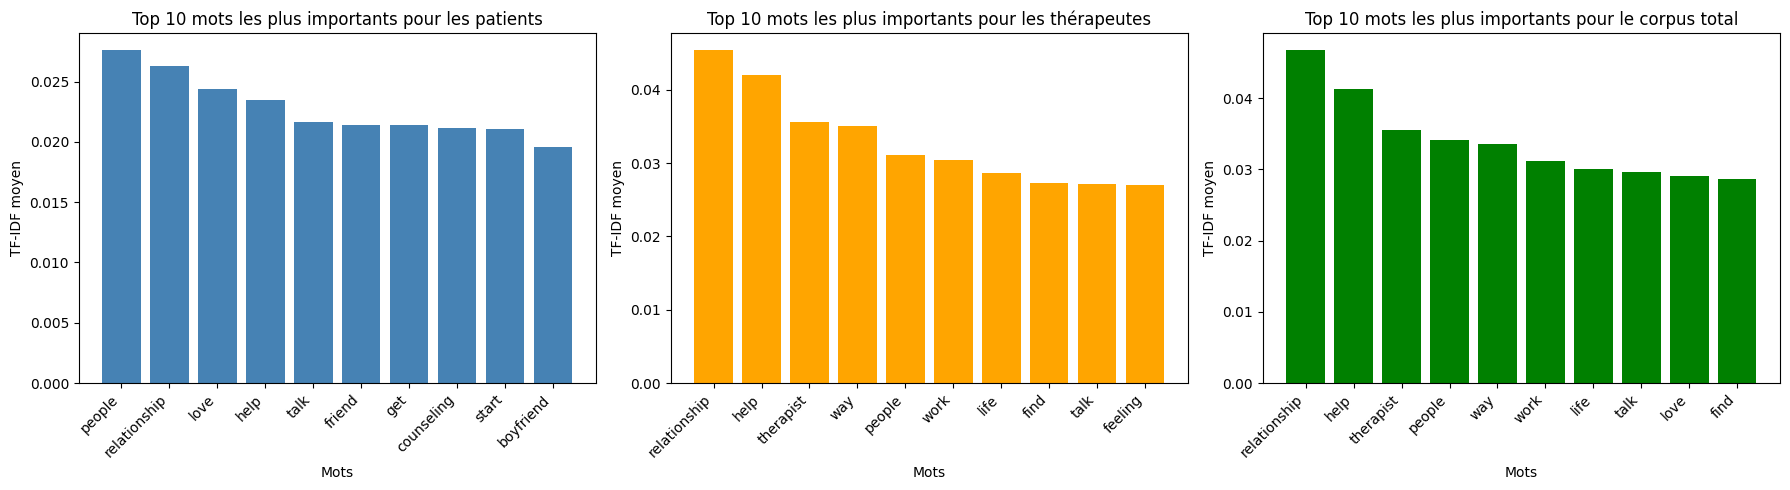

In [51]:
# On représente les 10 mots les plus importants pour les patients, les thérapeutes et global en barres
top_context = df_scores[['mot_context', 'tfidf_context']].sort_values('tfidf_context', ascending=False).head(10)
top_response = df_scores[['mot_response', 'tfidf_response']].sort_values('tfidf_response', ascending=False).head(10)
top_total = df_scores[['mot_total', 'tfidf_total']].sort_values('tfidf_total', ascending=False).head(10)

# On affiche sur 3 graphes différents les top 10 mots les plus importants pour les patients, les thérapeutes et global
plt.figure(figsize=(18, 5))
plt.subplot(131)
plt.bar(top_context['mot_context'], top_context['tfidf_context'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('TF-IDF moyen')
plt.title('Top 10 mots les plus importants pour les patients')
plt.subplot(132)
plt.bar(top_response['mot_response'], top_response['tfidf_response'], color='orange')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('TF-IDF moyen')
plt.title('Top 10 mots les plus importants pour les thérapeutes')
plt.subplot(133)
plt.bar(top_total['mot_total'], top_total['tfidf_total'], color='green')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('TF-IDF moyen')
plt.title('Top 10 mots les plus importants pour le corpus total')
plt.tight_layout()

plt.show()

#### Clustering

Maintenant que l'on a les résultats, on va devoir regroupper les mots similaires en cluster.

Tout d'abord, on doit choisir le nombre $K$, celui-ci correpond aux nombre de clusters total que l'on aura.  
Un des risque est de choisir un $K$ trop petit ou trop grand, au début on ne peut pas le deviner... Par contre, il existe une méthode pour pouvoir le trouver !  
**La méthode du coude** (elbow method) mesure la "perte d'information" quand on réduit le nombre de clusters. Au moment où la courbe commence à se stabiliser, on aura alors un nombre de groupes pertinent.
Une des autre méthodes est le **silhouette score**, celui-ci mesure la cohérence d'un cluster. Plus le score est proche de 1, plus les éléments d'un groupe sont proches entre eux et éloignés des autres.  

Dans notre cas on va utiliser la **Méthode du coude**.


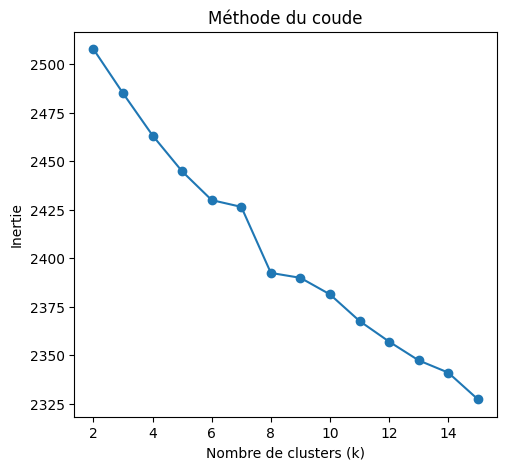

In [52]:
# On applique la méthode du coude sur la matrice TF-IDF totale pour trouver le nombre optimal de clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

tfidf_dense = tfidf_total.todense() # Nous permet d'accéder à la matrice 
tfidf_array = np.asarray(tfidf_dense) # On convertit en array numpy pour pouvoir l'utiliser dans KMeans
inertias = []
K_range = range(2, 16) # On teste de 2 à 10 clusters
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_array)
    inertias.append(kmeans.inertia_) #inertia_ est la somme des distances au carré entre les points et leur centre de cluster, plus elle est basse, mieux c'est

# Affichage de la courbe
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.show()

Ici, on remarque que l'inertie **diminue grandement jusqu'à $k=6$**, puis la courbe devient plus plate, ce qui suggère que **6 clusters pourraient être un bon choix**.  On va donc choisir **$k=6$** pour notre clustering final.

In [53]:
from sklearn.cluster import KMeans

K = 6
# la random_state est importante, cela nous permet de garder un même résultat à chaque exécution du code, sinon les clusters pourraient changer à chaque fois
kmeans_context = KMeans(n_clusters=K, random_state=42) 
kmeans_response = KMeans(n_clusters=K, random_state=42)
kmeans_total = KMeans(n_clusters=K, random_state=42)

kmeans_context.fit(tfidf_total)
kmeans_response.fit(tfidf_total)
kmeans_total.fit(tfidf_total)

df["cluster_total"] = kmeans_total.labels_
df["cluster_context"] = kmeans_context.labels_
df["cluster_response"] = kmeans_response.labels_

#### Interprétations des clusters

In [54]:
#Interprétation des clusters
for i in range(K):
    print(f"\nCluster {i} - Patients:")
    print(df[df["cluster_context"] == i]["Context_joined"].head(3)) # Affiche les 3 premiers textes du cluster pour les patients


Cluster 0 - Patients:
356    couple therapy session far everytime walk nerv...
357    couple therapy session far everytime walk nerv...
358    couple therapy session far everytime walk nerv...
Name: Context_joined, dtype: object

Cluster 1 - Patients:
105    try husband depressed ignore sad depressed pic...
106    try husband depressed ignore sad depressed pic...
107    try husband depressed ignore sad depressed pic...
Name: Context_joined, dtype: object

Cluster 2 - Patients:
0    feeling barely sleep worthless try contemplate...
1    feeling barely sleep worthless try contemplate...
2    feeling barely sleep worthless try contemplate...
Name: Context_joined, dtype: object

Cluster 3 - Patients:
18     feeling barely sleep worthless try contemplate...
132    life anymore figure keep distracted unfocused ...
134    smile fake happiness love person girlfriend ha...
Name: Context_joined, dtype: object

Cluster 4 - Patients:
23    issue address history sexual abuse breast canc...
24    i

In [55]:
for i in range(K):
    print(f"\nCluster {i} - Thérapeutes:")
    print(df[df["cluster_response"] == i]["Response_joined"].head(3)) # Affiche les 3 premiers textes du cluster pour les thérapeutes


Cluster 0 - Thérapeutes:
356    hello sorry experience feeling intense offer s...
357    uncomfortable talk life great detail normally ...
358    couple session make sense apprehensive therapy...
Name: Response_joined, dtype: object

Cluster 1 - Thérapeutes:
105    ouch hard deal spouse take seriously case plan...
106    hard hard understand depression having experie...
107    hard husband hear wife unhappy nature man tend...
Name: Response_joined, dtype: object

Cluster 2 - Thérapeutes:
0    worthless maybe find new people hang social co...
1    hello thank question seek advice feeling worth...
2    suggest get sleep impact look find life gratef...
Name: Response_joined, dtype: object

Cluster 3 - Thérapeutes:
18     oftentime change feeling build well relationsh...
132    sound benefit talk local mental health profess...
134    trust believe real reflect sad lose love patie...
Name: Response_joined, dtype: object

Cluster 4 - Thérapeutes:
23    let start concern bring counselling fa

In [56]:
for i in range(K):    
    print(f"\nCluster {i} - Total:")
    print(df[df["cluster_total"] == i][["Context_joined", "Response_joined"]].head(3)) # Affiche les 3 premiers textes du cluster pour le total


Cluster 0 - Total:
                                        Context_joined  \
356  couple therapy session far everytime walk nerv...   
357  couple therapy session far everytime walk nerv...   
358  couple therapy session far everytime walk nerv...   

                                       Response_joined  
356  hello sorry experience feeling intense offer s...  
357  uncomfortable talk life great detail normally ...  
358  couple session make sense apprehensive therapy...  

Cluster 1 - Total:
                                        Context_joined  \
105  try husband depressed ignore sad depressed pic...   
106  try husband depressed ignore sad depressed pic...   
107  try husband depressed ignore sad depressed pic...   

                                       Response_joined  
105  ouch hard deal spouse take seriously case plan...  
106  hard hard understand depression having experie...  
107  hard husband hear wife unhappy nature man tend...  

Cluster 2 - Total:
                  

Si on devait résumer ce que notre TF-IDF + cluster à trouvé:

|            | Cluster 0  | Cluster 1  | Cluster 2  | Cluster 3  | Cluster 4  | Cluster 5  |
|------------|:----------:|:----------:|:----------:|:----------:|:----------:|:----------:|
| Patient    | dépression sévère - idées suicidaires | mal-être général - perte de motivation | dépression sévère - fatigue mentale | thérapie de couple - anxiété | traumatisme - abus - maladie grave | problèmes familiaux - divorce - identité |
| Thérapeute | soutien initial - écoute - orientation générale | accompagnement émotionnel - relationnel | conseils pratiques - actions concrètes | accompagnement en thérapie de couple | suivi thérapeutique structuré - counselling | soutien familial - rôle parental |
| Global     | dépression sévère → écoute et orientation | mal-être diffus → accompagnement émotionnel | dépression → conseils pratiques | couple → accompagnement thérapeutique | traumatisme → suivi structuré | famille/divorce → soutien familial |

Les clusters sont basés sur des similarités lexicales et ne garantissent pas une séparations parfaite des thèmes, comme on peut le constater avec les cluster 0 et 3 des patients où la notion de dépression est présente dans les deux.  
On aurait pu réduire le nombre de cluster à 5 ou même 4 mais l'erreur est tellement minime qu'elle ne vaut pas la pène d'être rectifiée et même au contraire !  
Cela nous permet de voir que la dépression peut venir de thème différents, l'une est liée à la fatigue mentale tandis que l'autre à des idées suicidaires.  
On pourrais débattre sur le sens des mots et dire que la fatigue mentale entraine peut entrainer des idées suicidaires et donc une dépression mais malheureusement cela serait hors de mes compétences et celle du projet...  

Ormis ce petit détail, on peut remarquer que les clusters des patients et ceux des thérapeutes ont un véritable sens. Chez les patients, on trouve divers états émotionnels (dépression, anxiété, etc.), tandis que ches les thérapeutes, on observe plutôt des **stratégies de réponses**. Les thérapeutes adoptent différentes statégies de communication en fonction des émotions des patients. Ce détail semble tout a fait normal à première vue mais en réalité on démontre ici que les conversation ne sont pas (ou du moins dans la globalité) aléatoire.


On peut maintenant afficher les clusters sur un plan en 2 dimmensions.  
**Attentions !** On applatit le plan à très grande dimensions de TF-IDF sur un plan en 2D, c'est donc normal d'avoir des points qui sembles être dans le mauvais cluster, c'est simplement dû au fait qu'on est en 2D (on aurait surement pu voir la différence en 3D mais même là ce n'est pas sûr...).

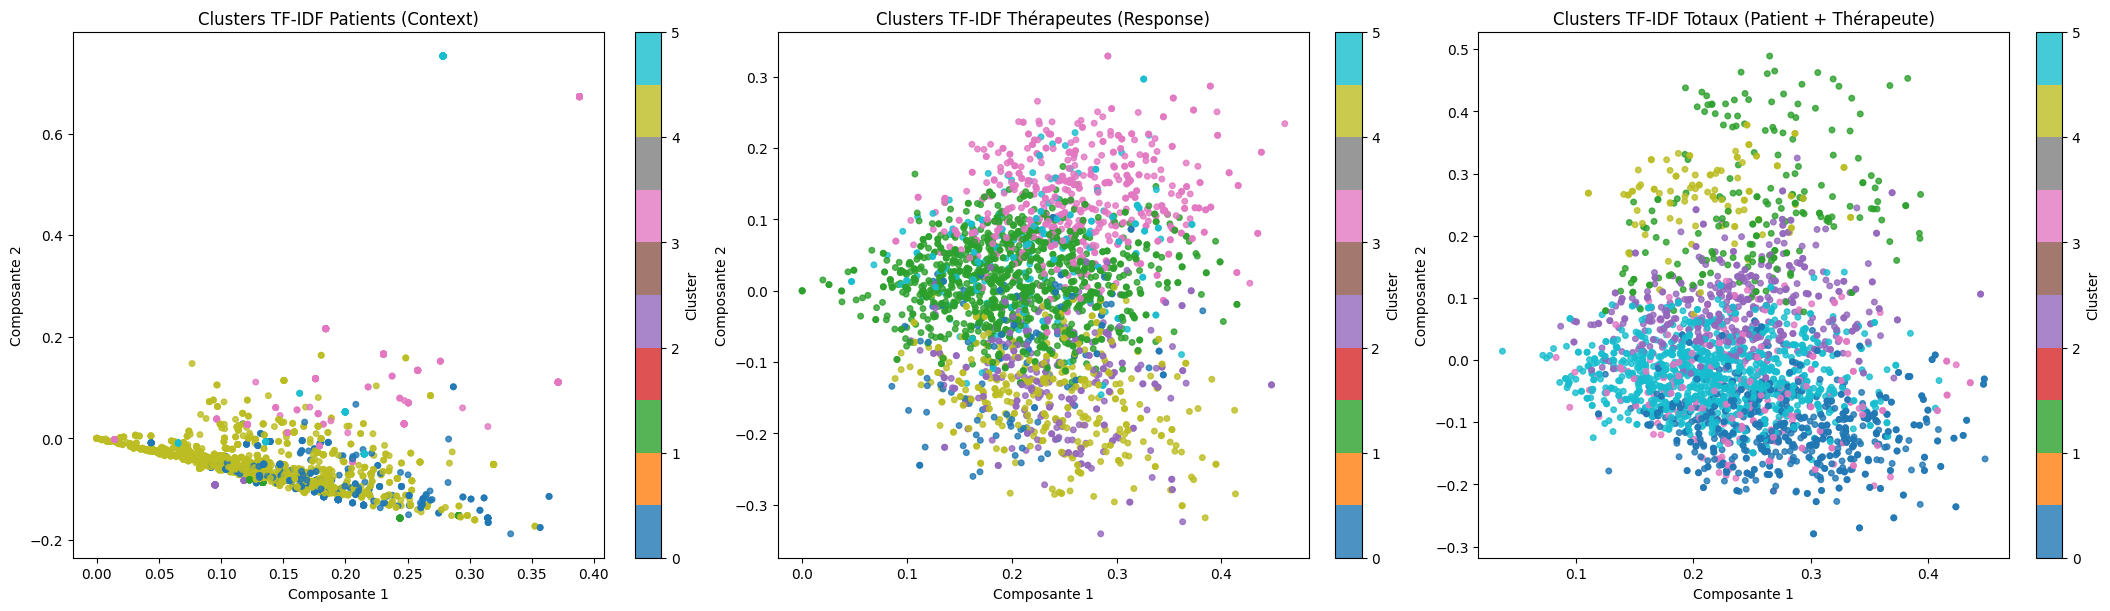

Répartition des clusters TF-IDF:

Patients:
cluster_tfidf_patient
0     457
1     112
2      46
3     223
4    1718
5     139
Name: count, dtype: int64

Thérapeutes:
cluster_tfidf_therapeute
0     125
1    1152
2     295
3     542
4     368
5     213
Name: count, dtype: int64

Total:
cluster_tfidf_total
0     643
1     203
2     472
3     270
4     103
5    1004
Name: count, dtype: int64


In [57]:
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Nombre de clusters (on garde K s'il est déjà défini)
n_clusters = K if 'K' in globals() else 6

# Clustering TF-IDF séparé pour patients, thérapeutes et total
kmeans_tfidf_context = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_tfidf_response = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_tfidf_total = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

df['cluster_tfidf_patient'] = kmeans_tfidf_context.fit_predict(tfidf_context)
df['cluster_tfidf_therapeute'] = kmeans_tfidf_response.fit_predict(tfidf_response)
df['cluster_tfidf_total'] = kmeans_tfidf_total.fit_predict(tfidf_total)

# Projection 2D adaptée aux matrices creuses TF-IDF
svd_context = TruncatedSVD(n_components=2, random_state=42)
svd_response = TruncatedSVD(n_components=2, random_state=42)
svd_total = TruncatedSVD(n_components=2, random_state=42)

context_2d_tfidf = svd_context.fit_transform(tfidf_context)
response_2d_tfidf = svd_response.fit_transform(tfidf_response)
total_2d_tfidf = svd_total.fit_transform(tfidf_total)

# Tracé des 3 graphes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

sc0 = axes[0].scatter(
    context_2d_tfidf[:, 0], context_2d_tfidf[:, 1],
    c=df['cluster_tfidf_patient'], cmap='tab10', s=16, alpha=0.8
)
axes[0].set_title('Clusters TF-IDF Patients (Context)')
axes[0].set_xlabel('Composante 1')
axes[0].set_ylabel('Composante 2')
fig.colorbar(sc0, ax=axes[0], label='Cluster')

sc1 = axes[1].scatter(
    response_2d_tfidf[:, 0], response_2d_tfidf[:, 1],
    c=df['cluster_tfidf_therapeute'], cmap='tab10', s=16, alpha=0.8
)
axes[1].set_title('Clusters TF-IDF Thérapeutes (Response)')
axes[1].set_xlabel('Composante 1')
axes[1].set_ylabel('Composante 2')
fig.colorbar(sc1, ax=axes[1], label='Cluster')

sc2 = axes[2].scatter(
    total_2d_tfidf[:, 0], total_2d_tfidf[:, 1],
    c=df['cluster_tfidf_total'], cmap='tab10', s=16, alpha=0.8
)
axes[2].set_title('Clusters TF-IDF Totaux (Patient + Thérapeute)')
axes[2].set_xlabel('Composante 1')
axes[2].set_ylabel('Composante 2')
fig.colorbar(sc2, ax=axes[2], label='Cluster')

plt.show()

print('Répartition des clusters TF-IDF:')
print('\nPatients:')
print(df['cluster_tfidf_patient'].value_counts().sort_index())
print('\nThérapeutes:')
print(df['cluster_tfidf_therapeute'].value_counts().sort_index())
print('\nTotal:')
print(df['cluster_tfidf_total'].value_counts().sort_index())

### Méthode 3: Utilisation Word Embedding couplé à un clustering

#### Qu'est ce que le Word Embedding ? (Avec **Word2Vec**)

Le Word Embedding (en français **plongement lexical** ou **plongement sémantique**) est une méthode d'apprentissage représentant les mots sous forme de **vecteurs de nombres réels**.  
Deux mots de sens proche ont des **vecteurs proches** dans l'espace mathématique et inversemment si leurs sens sont différents.

Contrairement à TF-IDF qui est une **représentation statistique** où on mesure à **quelle fréquence** un mot apparaît, ici on fait une représentation dite **sémantique**.  
Word2Vec apprend **ce que le mot veut dire** en regardant les mots qui l'entourent dans le corpus.  

Concrètement, pour TF-IDF, *"sad"* et *"depressed"* sont deux colonnes complètement indépendantes, le modèle ne sait pas qu'il sont synonymes. Pour Word2Vec en revanche, ces deux mots se trouvent proches dans l'espace vectoriel parce qu'ils apparaissent souvent dans les mêmes contextes (*"I feel sad"*, *"I feel depressed"*).

Ici, on parle de Word2Vec, celui-ci s'entraine sur un corpus visée, un autre modèle que l'on auraient pu utiliser est GloVe, qui est pré-entraîné sur des milliards de mots, donc prêt à l'emploi).

*sources*:
- <a href="https://fr.wikipedia.org/wiki/Word_embedding">Wikipedia - Word embedding</a>
- <a href="https://sti.eduscol.education.fr/sites/eduscol.education.fr.sti/files/ressources/pedagogiques/14960/14960-word-embedding-les-mots-et-le-machine-learning-ensps.pdf">Culture Sciences de l'Ingénieur - Word Embedding Les mots et le Machine Learning</a>
- <a href="https://www.geeksforgeeks.org/nlp/word-embeddings-in-nlp/">Geeks for Geeks - Word Embedding in NLP</a>

Pour cela on va devoir installer la librairie <code> gensim </code>

In [58]:
# pip install gensim

Word2Vec attend une liste de listes de tokens, ça tombe bien on a déjà tout fait aupparavent !

In [59]:
sentences_context = df['Context_clean'].tolist()
sentences_response = df['Response_clean'].tolist()

#On combien les deux pour que Word2Vec apprenne sur tout le corpus
all_sentences = sentences_context + sentences_response

print(f"Nombre de phrases pour les patients: {len(sentences_context)}")
print(f"Nombre de phrases pour les thérapeutes: {len(sentences_response)}")
print(f"Nombre total de phrases: {len(all_sentences)}")

print(f"Exemple de phrases: {all_sentences[0][:5]}")

Nombre de phrases pour les patients: 2695
Nombre de phrases pour les thérapeutes: 2695
Nombre total de phrases: 5390
Exemple de phrases: ['feeling', 'barely', 'sleep', 'worthless', 'try']


On entraine maintenant Word2Vec.  
Pour Word2Vec, il existe deux technique de NLP: 
- CBOW (Continuous Bag of Words)
- Skip-Gram

Les deux apprennent des vecteurs, **mais leur tâche d'entrainement est inversée**.  
CBOW prédit le mot cible à partir de son contexte tandis que Skip-Gram prédit le contexte à partir du mot cible.  
Dans notre cas, le plus avantageux est **Skip-Gram**, notre corpus est assez petit et spécialisé.Skip-Gram va, pour chaque mots, nous générer autant si ce n'est plus de mots. Pour notre petit corpus, c'est réalisable et peut compenser des possibles manque de données qu'on pourrait avoir.

CBOW, lui, peut traiter des corpus très vite même si ils contiennent des millions de phrases ! Ce qui prend sens quand on regarde son fonctionnement (plutôt bien expliqué sur les <a href="http://w3.erss.univ-tlse2.fr/UETAL/2018-2019/Tuto-embeddings.pdf">diapositives de l'Université de Jean Jaures</a>), la moyenne du contexte **lisse le bruit statique**, ce qui peut **effacer des nuances de mots qui peuvent nous intéresser**.

In [60]:
from gensim.models import Word2Vec

**Par la suite, pour éviter de devoir relancer le même modèle en boucle, on pourra le charger**

In [61]:
model = Word2Vec.load("word2vec_therapie.model")

In [62]:

model = Word2Vec(
    sentences=all_sentences,
    vector_size=100,  # taille des vecteurs de mots
    window=5,         # contexte de 5 mots de chaque côté
    min_count=3,      # ignore les mots qui apparaissent moins de 3 fois
    workers=4,        # nombre de threads pour l'entraînement
    epochs=10,        # nombre de passes (d'itérations) sur le corpus
    seed=42,          # pour la reproductibilité
    sg=1              # utilise Skip-gram (sg=0 pour CBOW)
)

On vérifie que le modèle a bien appris

In [63]:
# Mots les plus proches de "anxiety"
print("\nMots les plus proches de 'anxiety':")
for mot in model.wv.most_similar("anxiety", topn=5):
    print(f"- {mot[0]} (similarité: {mot[1]:.4f})")

# Mots les plus proches de "feel"
print("\nMots les plus proches de 'worthless':")
for mot in model.wv.most_similar("worthless", topn=5):
    print(f"- {mot[0]} (similarité: {mot[1]:.4f})")

# Similarité entre deux mots
print(f"\nSimilarité entre sad et depressed : {model.wv.similarity('sad', 'depressed'):.3f}")
print(f"Similarité entre sad et sleep : {model.wv.similarity('sad', 'sleep'):.3f}")


Mots les plus proches de 'anxiety':
- attack (similarité: 0.6471)
- panic (similarité: 0.6311)
- anxierty (similarité: 0.5921)
- tolerable (similarité: 0.5913)
- vivid (similarité: 0.5836)

Mots les plus proches de 'worthless':
- contemplated (similarité: 0.8494)
- barely (similarité: 0.8219)
- shit (similarité: 0.7579)
- fix (similarité: 0.6938)
- explode (similarité: 0.6530)

Similarité entre sad et depressed : 0.568
Similarité entre sad et sleep : 0.232


On remarque que la similarité entre *sad* et *depressed* est bien plus haute que *sad* et *sleep*.  
Cela signifie que le modèle a bien appris !

Maintenant on va devoir **vectoriser** chaque conversation et faire le **clustering**

In [64]:
def vectoriser_conversation(tokens, model):
    """
    Retourne la moyenne des vecteurs des tokens présents
    dans le vocabulaire Word2Vec
    Retourne un vecteur nul si aucun token n'est dans le vocabulaire
    """
    vecteurs = [
        model.wv[token]
        for token in tokens
        if token in model.wv
    ]
    if len(vecteurs) == 0: # Si aucun token n'est dans le vocabulaire, on retourne un vecteur nul
        return np.zeros(model.vector_size)
    return np.mean(vecteurs, axis=0)

# On applique sur les patients et les thérapeutes
context_vectors = np.array([
    vectoriser_conversation(token,model)
    for token in df['Context_clean']
])

response_vectors = np.array([
    vectoriser_conversation(token,model)
    for token in df['Response_clean']
])

# Pour le clustering: on fusionne patient et thérapeute
combined_vectors = (context_vectors + response_vectors)/2

In [65]:
print(f"Shape des vecteurs de contexte: {context_vectors.shape}")
print(f"Shape des vecteurs de réponse: {response_vectors.shape}")
print(f"Shape des vecteurs combinés: {combined_vectors.shape}")

Shape des vecteurs de contexte: (2695, 100)
Shape des vecteurs de réponse: (2695, 100)
Shape des vecteurs combinés: (2695, 100)


Pour éviter de toujours réentraîner le modele on le sauvegarde

In [66]:
model.save("word2vec_therapie.model")

In [67]:
# Interprétation des clusters
n_clusters = 6
kmeans_w2v = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

df['cluster_w2v'] = kmeans_w2v.fit_predict(combined_vectors)
for i in range(n_clusters):
    print(f"\nCluster {i} - Patients:")
    print(df[df["cluster_w2v"] == i]["Context_joined"].head(3)) # Affiche les 3 premiers textes du cluster pour les patients


Cluster 0 - Patients:
105    try husband depressed ignore sad depressed pic...
106    try husband depressed ignore sad depressed pic...
107    try husband depressed ignore sad depressed pic...
Name: Context_joined, dtype: object

Cluster 1 - Patients:
356    couple therapy session far everytime walk nerv...
357    couple therapy session far everytime walk nerv...
358    couple therapy session far everytime walk nerv...
Name: Context_joined, dtype: object

Cluster 2 - Patients:
89    ago make love wife reason lose erection early ...
90    ago make love wife reason lose erection early ...
93    ago make love wife reason lose erection early ...
Name: Context_joined, dtype: object

Cluster 3 - Patients:
0    feeling barely sleep worthless try contemplate...
1    feeling barely sleep worthless try contemplate...
2    feeling barely sleep worthless try contemplate...
Name: Context_joined, dtype: object

Cluster 4 - Patients:
23    issue address history sexual abuse breast canc...
24    issu

In [68]:
df['cluster_w2v'] = kmeans_w2v.fit_predict(combined_vectors)
for i in range(n_clusters):
    print(f"\nCluster {i} - Thérapeutes:")
    print(df[df["cluster_w2v"] == i]["Response_joined"].head(3)) # Affiche les 3 premiers textes du cluster pour les thérapeutes


Cluster 0 - Thérapeutes:
105    ouch hard deal spouse take seriously case plan...
106    hard hard understand depression having experie...
107    hard husband hear wife unhappy nature man tend...
Name: Response_joined, dtype: object

Cluster 1 - Thérapeutes:
356    hello sorry experience feeling intense offer s...
357    uncomfortable talk life great detail normally ...
358    couple session make sense apprehensive therapy...
Name: Response_joined, dtype: object

Cluster 2 - Thérapeutes:
89    step medical rule sure problem psychological e...
90    work man type situation suggest medical examin...
93    doctor ed cause number physical condition chec...
Name: Response_joined, dtype: object

Cluster 3 - Thérapeutes:
0    worthless maybe find new people hang social co...
1    hello thank question seek advice feeling worth...
2    suggest get sleep impact look find life gratef...
Name: Response_joined, dtype: object

Cluster 4 - Thérapeutes:
23    let start concern bring counselling fact 

In [69]:
df['cluster_w2v'] = kmeans_w2v.fit_predict(combined_vectors)
for i in range(n_clusters):
    print(f"\nCluster {i} - global:")
    print(df[df["cluster_w2v"] == i][["Context_joined", "Response_joined"]].head(3)) # Affiche les 3 premiers textes du cluster pour les patients et thérapeutes


Cluster 0 - global:
                                        Context_joined  \
105  try husband depressed ignore sad depressed pic...   
106  try husband depressed ignore sad depressed pic...   
107  try husband depressed ignore sad depressed pic...   

                                       Response_joined  
105  ouch hard deal spouse take seriously case plan...  
106  hard hard understand depression having experie...  
107  hard husband hear wife unhappy nature man tend...  

Cluster 1 - global:
                                        Context_joined  \
356  couple therapy session far everytime walk nerv...   
357  couple therapy session far everytime walk nerv...   
358  couple therapy session far everytime walk nerv...   

                                       Response_joined  
356  hello sorry experience feeling intense offer s...  
357  uncomfortable talk life great detail normally ...  
358  couple session make sense apprehensive therapy...  

Cluster 2 - global:
               

Si on devait résumer nos résultats dans un tableau:

|            | Cluster 0  | Cluster 1  | Cluster 2  | Cluster 3  | Cluster 4  | Cluster 5  |
|------------|:----------:|:----------:|:----------:|:----------:|:----------:|:----------:|
| Patient    | dépression sévère - idées suicidaires | problèmes sexuels - santé physique | thérapie de couple - anxiété | mal-être quotidien - divorce | anxiété - troubles du sommeil | traumatisme - abus - maladie grave |
| Thérapeute | soutien émotionnel - conseils généraux | orientation médicale | accompagnement en thérapie de couple | introspection - gestion émotionnelle | conseils thérapeutiques | accompagnement structuré - conseils |
| Global     | dépression → soutien émotionnel | problème physique → orientation médicale | couple → thérapie | mal-être → introspection | anxiété → gestion thérapeutique | traumatisme → suivi structuré |

Ce qu'on peut remarquer par rapport à TF-IDF c'est que avec Word2Vec, les clusters sont certe très similaires mais ont une **meilleure séparation des thèmes**, en particulier pour les patients où le sentiment de dépression est réunit dans un seul cluster, tandis que pour TF-IDF il existait deux types de dépressions.  
Contrairement à TF-IDF, qui repose uniquement sur la fréquence des mots, Word2Vec capture le contexte sémantique, ce qui permet de regrouper des situations similaires même lorsque le vocabulaire diffère.  
Du côté des thérapeutes, on voit aussi apparaitre des **"stratégies" plus distinctes**.  

On observe également une meilleure cohérence entre les problématiques
des patients et les réponses des thérapeutes, chaque type de problème
étant associé à une stratégie d’accompagnement adaptée.

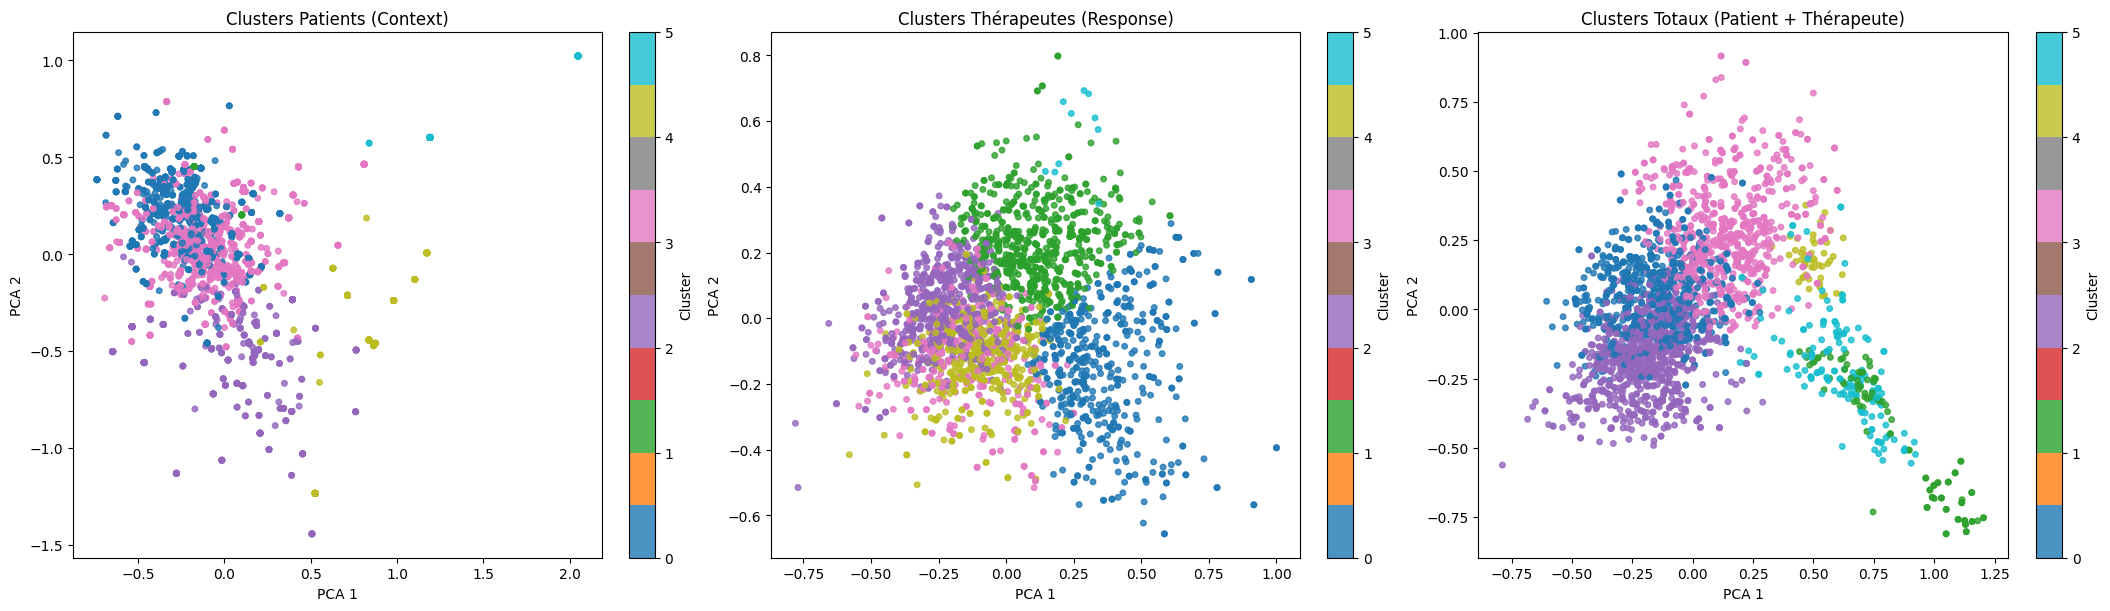

Répartition des clusters:

Patients:
cluster_patient
0     893
1      21
2     414
3    1084
4     195
5      88
Name: count, dtype: int64

Thérapeutes:
cluster_therapeute
0    494
1    643
2    683
3    388
4    477
5     10
Name: count, dtype: int64

Total:
cluster_total
0    749
1    100
2    940
3    703
4     47
5    156
Name: count, dtype: int64


In [70]:
from sklearn.decomposition import PCA 

# Nombre de clusters (utilise K si déjà défini dans le notebook)
n_clusters = K if 'K' in globals() else 6

# Clustering séparé: patients (context), thérapeutes (response), total (moyenne)
kmeans_context = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_response = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_total = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

df['cluster_patient'] = kmeans_context.fit_predict(context_vectors)
df['cluster_therapeute'] = kmeans_response.fit_predict(response_vectors)
df['cluster_total'] = kmeans_total.fit_predict(combined_vectors)

# Réduction en 2D pour visualiser les clusters
pca_context = PCA(n_components=2, random_state=42)
pca_response = PCA(n_components=2, random_state=42)
pca_total = PCA(n_components=2, random_state=42)

context_2d = pca_context.fit_transform(context_vectors)
response_2d = pca_response.fit_transform(response_vectors)
total_2d = pca_total.fit_transform(combined_vectors)

# Tracé des 3 graphes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

sc0 = axes[0].scatter(context_2d[:, 0], context_2d[:, 1], c=df['cluster_patient'], cmap='tab10', s=16, alpha=0.8)
axes[0].set_title('Clusters Patients (Context)')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
fig.colorbar(sc0, ax=axes[0], label='Cluster')

sc1 = axes[1].scatter(response_2d[:, 0], response_2d[:, 1], c=df['cluster_therapeute'], cmap='tab10', s=16, alpha=0.8)
axes[1].set_title('Clusters Thérapeutes (Response)')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
fig.colorbar(sc1, ax=axes[1], label='Cluster')

sc2 = axes[2].scatter(total_2d[:, 0], total_2d[:, 1], c=df['cluster_total'], cmap='tab10', s=16, alpha=0.8)
axes[2].set_title('Clusters Totaux (Patient + Thérapeute)')
axes[2].set_xlabel('PCA 1')
axes[2].set_ylabel('PCA 2')
fig.colorbar(sc2, ax=axes[2], label='Cluster')

plt.show()

# Aperçu du nombre d'éléments par cluster
print('Répartition des clusters:')
print('\nPatients:')
print(df['cluster_patient'].value_counts().sort_index())
print('\nThérapeutes:')
print(df['cluster_therapeute'].value_counts().sort_index())
print('\nTotal:')
print(df['cluster_total'].value_counts().sort_index())

### Méthode 4: Entrainement d'un **modèle probabiliste** LDA

#### Tout d'abord, **qu'est ce que le LDA** ?

Le *Latent Dirichlet Allocation* (ou l'Allocation de Dirichlet Latente en français) est un **modèle génératif probabiliste** permettant de décrouvrir des **sujets centraux et leur distributions** dans un ensemble de document.  
C'est une approche bayésienne (approche basée sur le degrées de croyance en un évènement) qui permet par la suite une **modélisation thématique.**  

```mermaid
flowchart LR
    A[Conversation: 
    feel anxious panic sleep 
    nightmare relationship 
    lonely therapy help cope 
    stress worry fear family 
    support] --> B(LDA
    Modèle probabiliste)
    B --> C(mélange de thèmes)
    C -->|45%| D[Anxiété]
    C -->|30%| E[Sommeil]
    C -->|25%| F[Relations]
```  


Contrairement à K-Means où chaque documents appartient à UN seul cluster, LDA assigne à chaque conversation un **mélange de thèmes avec des probabilités**. Il suppose que chaque document est un mélange de thèmes, et que chaque thème est un distribution de mots. Le mot *"latent"* signifie que les thèmes sont cachés, **c'est LDA qui les fait émerger**.
Il choisit un mélange de thèmes (avec $K$ le nombre de thèmes), pour chaque mot il en tire un thème et ensuite tire tout les mots représentant ce thème.  

Prenons un exemple: la phrase *"I feel sad and anxious"* aura peut être:
- 70% dépression
- 30% anxiété  

Contrairement à K-Means qui aurait définit un unique cluster par document (dans notre cas une cellule) ici on a plusieurs thèmes par documents.

En sortie on aura **deux tableaux de probabilités**: un premier qui définit quels mots caractérisent chaque thèmes (distribution sur le **vocabulaire**) et un second qui définit dans quelle proportion chaque conversation aborde chaque thème (distribution sur les **thèmes**). 

*sources:*
- <a href="https://fr.wikipedia.org/wiki/Allocation_de_Dirichlet_latente">Wikipedia - Allocation de Dirichlet latente</a>
- <a href="https://www.ibm.com/fr-fr/think/topics/latent-dirichlet-allocation">IBM - Qu’est-ce que l’allocation latente Dirichlet (LDA) ?</a>

On va devoir alors:
- créer notre dictionnaire
- créer notre corpus, celui-ci aura la structure suivante: ```[(mot_id, fréquence)]```
- entrainer le LDA, comme pour Word2Vec

In [71]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel


N_TOPICS = 6
PASSES = 15

def train_lda(texts, n_topics=N_TOPICS, passes=PASSES, label=""):
    """Entraîne un modèle LDA sur une liste de listes de tokens."""
    dictionary = Dictionary(texts)

    # Filtrer les extrêmes : mots trop rares ou trop fréquents
    dictionary.filter_extremes(no_below=5, no_above=0.85)

    corpus = [dictionary.doc2bow(text) for text in texts]

    model = LdaModel(
        corpus=corpus,          # corpus au format BoW
        id2word=dictionary,     # mapping id -> mot
        num_topics=n_topics,    # nombre de topics à extraire (à ajuster !)
        random_state=42,        # pour la reproductibilité
        passes=passes,          # nombre de passes sur le corpus pour améliorer la convergence
    )

    print(f"\n{'='*50}")
    print(f"Topics — {label}")
    print('='*50)
    for i, topic in model.print_topics(num_words=8):
        print(f"Topic {i}: {topic}")

    return model, corpus, dictionary

Maintenant qu'on a bien tout initialisé, on va regarder les résultats pour les patients, thérapeutes et en générale.

In [72]:
# --- Patients ---
lda_context, corpus_context, dict_context = train_lda(
    df['Context_clean'].tolist(),
    label="Patients"
)


Topics — Patients
Topic 0: 0.019*"relationship" + 0.017*"husband" + 0.017*"child" + 0.016*"listen" + 0.013*"cheat" + 0.013*"get" + 0.013*"woman" + 0.012*"past"
Topic 1: 0.027*"relationship" + 0.015*"people" + 0.013*"person" + 0.011*"help" + 0.011*"dad" + 0.011*"make" + 0.011*"family" + 0.011*"past"
Topic 2: 0.029*"love" + 0.024*"friend" + 0.020*"talk" + 0.016*"boyfriend" + 0.014*"right" + 0.013*"therapist" + 0.013*"work" + 0.012*"try"
Topic 3: 0.020*"anxiety" + 0.019*"help" + 0.018*"talk" + 0.015*"friend" + 0.015*"feeling" + 0.014*"get" + 0.013*"try" + 0.013*"take"
Topic 4: 0.021*"thought" + 0.017*"boyfriend" + 0.017*"girl" + 0.017*"life" + 0.016*"have" + 0.014*"stop" + 0.013*"cry" + 0.013*"month"
Topic 5: 0.021*"normal" + 0.019*"issue" + 0.017*"wife" + 0.017*"therapy" + 0.014*"walk" + 0.013*"voice" + 0.013*"couple" + 0.012*"self"


In [73]:
# --- Thérapeutes ---
lda_response, corpus_response, dict_response = train_lda(
    df['Response_clean'].tolist(),
    label="Thérapeutes"
)


Topics — Thérapeutes
Topic 0: 0.029*"relationship" + 0.017*"feeling" + 0.014*"love" + 0.012*"help" + 0.011*"partner" + 0.010*"couple" + 0.009*"way" + 0.008*"friend"
Topic 1: 0.024*"parent" + 0.019*"child" + 0.015*"way" + 0.013*"talk" + 0.011*"daughter" + 0.010*"mom" + 0.009*"family" + 0.009*"ask"
Topic 2: 0.035*"relationship" + 0.014*"way" + 0.012*"partner" + 0.011*"person" + 0.010*"change" + 0.008*"work" + 0.008*"people" + 0.008*"question"
Topic 3: 0.017*"help" + 0.017*"therapist" + 0.016*"people" + 0.015*"thought" + 0.014*"work" + 0.014*"therapy" + 0.013*"client" + 0.013*"find"
Topic 4: 0.018*"therapist" + 0.013*"find" + 0.012*"people" + 0.010*"help" + 0.009*"way" + 0.008*"life" + 0.008*"self" + 0.007*"woman"
Topic 5: 0.025*"help" + 0.016*"anxiety" + 0.011*"way" + 0.011*"thought" + 0.009*"experience" + 0.009*"depression" + 0.008*"talk" + 0.008*"work"


In [74]:
# --- Global (patients + thérapeutes combinés) ---
texts_global = (df['Context_clean'] + df['Response_clean']).tolist()
lda_global, corpus_global, dict_global = train_lda(
    texts_global,
    label="Global"
)


Topics — Global
Topic 0: 0.030*"thought" + 0.025*"anxiety" + 0.023*"help" + 0.010*"way" + 0.008*"life" + 0.008*"people" + 0.008*"fear" + 0.007*"have"
Topic 1: 0.022*"child" + 0.015*"parent" + 0.013*"daughter" + 0.012*"mom" + 0.012*"way" + 0.011*"live" + 0.011*"help" + 0.010*"family"
Topic 2: 0.016*"help" + 0.015*"people" + 0.014*"way" + 0.013*"friend" + 0.012*"therapist" + 0.011*"therapy" + 0.010*"feeling" + 0.010*"talk"
Topic 3: 0.034*"relationship" + 0.019*"love" + 0.010*"partner" + 0.010*"work" + 0.009*"friend" + 0.009*"boyfriend" + 0.009*"talk" + 0.009*"ask"
Topic 4: 0.017*"relationship" + 0.013*"therapist" + 0.013*"sex" + 0.013*"people" + 0.011*"issue" + 0.011*"work" + 0.011*"help" + 0.010*"way"
Topic 5: 0.015*"depression" + 0.014*"help" + 0.012*"client" + 0.011*"counselor" + 0.010*"find" + 0.010*"work" + 0.009*"therapist" + 0.009*"talk"


Si on devait résumer nos résultats dans un tableau:

|            | Topic 0  | Topic 1  | Topic 2  | Topic 3  | Topic 4  | Topic 5  |
|------------|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| Patient    | famille - vie quotidienne - anxiété | dépression - addictions - recherche d’aide | relations sociales - passé - pensées | thérapie de couple - anxiété | sexualité - anxiété - estime de soi | relations amoureuses - interactions sociales |
| Thérapeute | suivi thérapeutique - rôle du thérapeute | parentalité - conseils familiaux | relations de couple | bruit (espagnol résiduel) | gestion des pensées - émotions | dépression - anxiété - accompagnement |
| Global     | santé / sexualité / recherche d’aide | communication - écoute - compréhension | anxiété - pensées - soutien | famille / enfants | thérapie / counseling | relations de couple |

On remarque que le LDA a permis d'identifier des thématiques principales au sein du corpus, telles que les relations de couples, la parentalité, les troubles anxieux et le suivi thérapeutique.

Contrairement aux méthodes de clustering, ici chaque documents peut être associé à plusieurs thèmes, ce qui donne des résultats plus flexibles.

#### Quelle méthode est la meilleur ?

Disons que **ces méthodes sont complémentaires plutôt que concurrentes.**  
Le modèle LDA apparaît comme le plus pertinent pour l'analyse thématique car il permet d'identifier des sujets clairement interprétables et cohérents avec le domaine étudié.

Cepandant, en terme de **qualité de clustering**, l'approche basée sur Word2Vec **offre de meilleur résultats que TF-IDF**, en capturant les similarités sémantiques entre les textes.

Et enfin, LDA est le plus impactant pour **l'interprétation des données**, tandis que Word2Vec est le plus performant pour le regroupement des documents.

| Méthode             | Avantages                                                                | Inconvénients                                                                |
|---------------------|--------------------------------------------------------------------------|------------------------------------------------------------------------------|
| TF-IDF + KMeans     | Simple à implémenter<br>Rapide à calculer<br>Bonne première approche     | Ne capture pas le sens des mots<br>Clusters redondants<br>Séparation brute   |
| Word2Vec + KMeans   | Capture les relations sémantiques<br>Meilleure qualité de clustering<br>Détecte des thèmes plus fins | Plus complexe à mettre en place<br>Résultats parfois moins interprétables directement |
| LDA                 | Thèmes clairement interprétables<br>Modèle probabiliste flexible<br>Un document peut appartenir à plusieurs thèmes | Sensible au prétraitement<br>Peut produire du bruit<br>Choix du nombre de topics délicat |
